In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns

In [2]:
df = pd.read_csv('../Village_Wise_Data/Bajhedi.csv')

In [3]:
df.head()

,Timestamp,Survey type,Village Name,Household ID (House No.),Name of Head of Household,Gender,Contact Number of Household,Social Category,Total Family Members,Main Occupation,...,Livelihood Schemes [PM Fasal Bima],Livelihood Schemes [Pension Schemes],Awareness about Gram Sabha meetings,Participation in village development,Major village issues,Most urgent need of the village,Suggestions for village development,Enumerator Name,UID,Date
0,01-12-2026 13:22,Baseline,Bajhedi,NaN,Mohan Singh,Male,9.914105e+09,General,4.0,Service,...,Aware,Aware,No,Occasional,"Water, Education, Employment",Road improvements,Making of roads,Hitanshi,25bbl70047,01-12-2026
1,01-12-2026 13:48,Baseline,Bajhedi,NaN,Gurinder kaur,Female,8.872445e+09,General,4.0,Business,...,Not Aware,Not Aware,Yes,Never,"Water, Health, Environment","Transport, Dispensary and pond purification",Regular transport and dispensary,Pushp Ankit kotwal,25bbl70011,01-12-2026
2,01-12-2026 12:52,Baseline,Bajhedi,NaN,Lokesh kumar,Male,9.366641e+08,General,3.0,Business,...,Aware,Aware,Yes,Never,"Water, Health, Environment","Transport, pond should be clean and dispensary",Regular transport and dispensary,Pushp Ankit kotwal,25bbl70011,01-12-2026
3,01-12-2026 12:37,Baseline,Bajhedi,NaN,Nechhater singh,Male,NaN,OBC,6.0,Business,...,Aware,Aware,Yes,Never,"Employment, Environment",Need road,Electricity is required,Ridhi,25bbl70059 25bbl70264,01-12-2026
4,01-12-2026 12:56,Baseline,Bajhedi,NaN,mohan Singh,Male,NaN,OBC,4.0,Labour,...,Not Aware,Not Aware,Yes,Occasional,"Health, Education, Employment, Environment",Need roads,They need access to internet,RIDHII chhayank,25bbl70059 25bbl70264,01-12-2026


In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (84, 75)


In [5]:
df.columns = df.columns.str.strip()
df['Total Family Members'] = pd.to_numeric(df['Total Family Members'], errors='coerce')

In [6]:
missing_values = df.isnull().sum().reset_index()
missing_values.columns = ['Column Name', 'Missing Count']
missing_values[missing_values['Missing Count'] > 0]

,Column Name,Missing Count
3,Household ID (House No.),66
6,Contact Number of Household,47
15,Pregnant women received ANC services,23
17,Nutritional issues of children,84
18,Common diseases,40
27,Type of school,12
30,Reason for dropout,22
31,Access to digital devices,4
42,Drainage system,4
48,Renewable energy usage,67


In [7]:
df.columns

Index(['Timestamp', 'Survey type', 'Village Name', 'Household ID (House No.)',
       'Name of Head of Household', 'Gender', 'Contact Number of Household',
       'Social Category', 'Total Family Members', 'Main Occupation',
       'Approx. Annual Household Income',
       'Distance to nearest health facility', 'Type of facility used',
       'ASHA/ANM visit', 'Immunization status of children (0-5)',
       'Pregnant women received ANC services',
       'Last delivery was institutional  (in any hospital)',
       'Nutritional issues  of children', 'Common diseases',
       'Toilet availability', 'Handwashing with soap',
       'Health Schemes   [Ayushman Bharat (PM-JAY)]',
       'Health Schemes   [Janani Suraksha Yojana]',
       'Health Schemes   [Janani Shishu Suraksha Karyakram]',
       'Health Schemes   [Poshan Abhiyaan / ICDS]',
       'Literacy status of household', 'Children enrolled in school',
       'Type of school', 'Distance to nearest school',
       'School dropout case

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 75 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Timestamp                                              84 non-null     object 
 1   Survey type                                            84 non-null     object 
 2   Village Name                                           84 non-null     object 
 3   Household ID (House No.)                               18 non-null     object 
 4   Name of Head of Household                              84 non-null     object 
 5   Gender                                                 84 non-null     object 
 6   Contact Number of Household                            37 non-null     float64
 7   Social Category                                        84 non-null     object 
 8   Total Family Members                                

# Socio-Economic Indicators

# 1. Income Distribution Index

In [9]:
income_counts = df['Approx. Annual Household Income'].value_counts()

In [10]:
percentage_income = (income_counts/income_counts.sum())*100
percentage_income

Approx. Annual Household Income
<1 lakh     48.809524
1-3 lakh    33.333333
3-5 lakh    11.904762
>5 lakh      5.952381
Name: count, dtype: float64

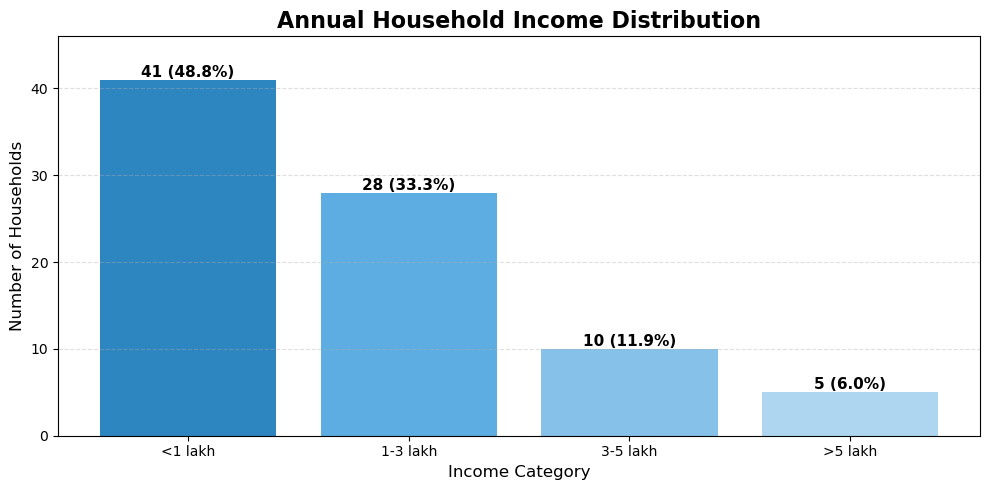

In [11]:
order = ['<1 lakh', '1-3 lakh', '3-5 lakh', '>5 lakh']
income_counts = df['Approx. Annual Household Income'].value_counts()
income_counts = income_counts[order]

plt.figure(figsize=(10,5))

colors = ['#2E86C1', '#5DADE2', '#85C1E9', '#AED6F1']
bars = plt.bar(income_counts.index, income_counts.values, color=colors)

total = income_counts.sum()

for bar in bars:
    height = bar.get_height()
    percent = (height / total) * 100
    
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{int(height)} ({percent:.1f}%)',
             ha='center',
             va='bottom',
             fontsize=11,
             fontweight='bold')

plt.title("Annual Household Income Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Income Category", fontsize=12)
plt.ylabel("Number of Households", fontsize=12)
plt.ylim(0, income_counts.values.max()+5)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# 2. Occupational Diversity Indicator

In [12]:
occupation_dist = df['Main Occupation'].value_counts(normalize=True) * 100
occupation_dist = occupation_dist.round(2)
print(occupation_dist)

Main Occupation
Agriculture              48.81
Labour                   20.24
Service                  17.86
Business                  5.95
Agriculture, Service      2.38
Agriculture, Business     1.19
Labour, Service           1.19
Service, Business         1.19
Agriculture, Labour       1.19
Name: proportion, dtype: float64


In [13]:
df['Main Occupation'].value_counts()

Main Occupation
Agriculture              41
Labour                   17
Service                  15
Business                  5
Agriculture, Service      2
Agriculture, Business     1
Labour, Service           1
Service, Business         1
Agriculture, Labour       1
Name: count, dtype: int64

In [14]:
df['Approx. Annual Household Income'] = df['Approx. Annual Household Income'].str.strip()
df['Main Occupation'] = df['Main Occupation'].str.strip()

In [15]:
order = ['<1 lakh', '1-3 lakh', '3-5 lakh', '>5 lakh']
df['Approx. Annual Household Income'] = pd.Categorical(
    df['Approx. Annual Household Income'],
    categories=order,
    ordered=True)

income_occupation = pd.crosstab(
    df['Main Occupation'],
    df['Approx. Annual Household Income'])
income_occupation

Approx. Annual Household Income,<1 lakh,1-3 lakh,3-5 lakh,>5 lakh
Main Occupation,,,,
Agriculture,22,13,5,1
"Agriculture, Business",0,1,0,0
"Agriculture, Labour",0,1,0,0
"Agriculture, Service",1,1,0,0
Business,0,2,1,2
Labour,14,3,0,0
"Labour, Service",0,1,0,0
Service,4,5,4,2
"Service, Business",0,1,0,0


In [16]:
occupations = df['Main Occupation'].value_counts().index
income_occupation = income_occupation.loc[occupations]
income_occupation

Approx. Annual Household Income,<1 lakh,1-3 lakh,3-5 lakh,>5 lakh
Main Occupation,,,,
Agriculture,22,13,5,1
Labour,14,3,0,0
Service,4,5,4,2
Business,0,2,1,2
"Agriculture, Service",1,1,0,0
"Agriculture, Business",0,1,0,0
"Labour, Service",0,1,0,0
"Service, Business",0,1,0,0
"Agriculture, Labour",0,1,0,0


In [17]:
top_occupations = df['Main Occupation'].value_counts().head(5).index
income_occupation = income_occupation.loc[top_occupations]

In [18]:
income_occupation

Approx. Annual Household Income,<1 lakh,1-3 lakh,3-5 lakh,>5 lakh
Main Occupation,,,,
Agriculture,22,13,5,1
Labour,14,3,0,0
Service,4,5,4,2
Business,0,2,1,2
"Agriculture, Service",1,1,0,0


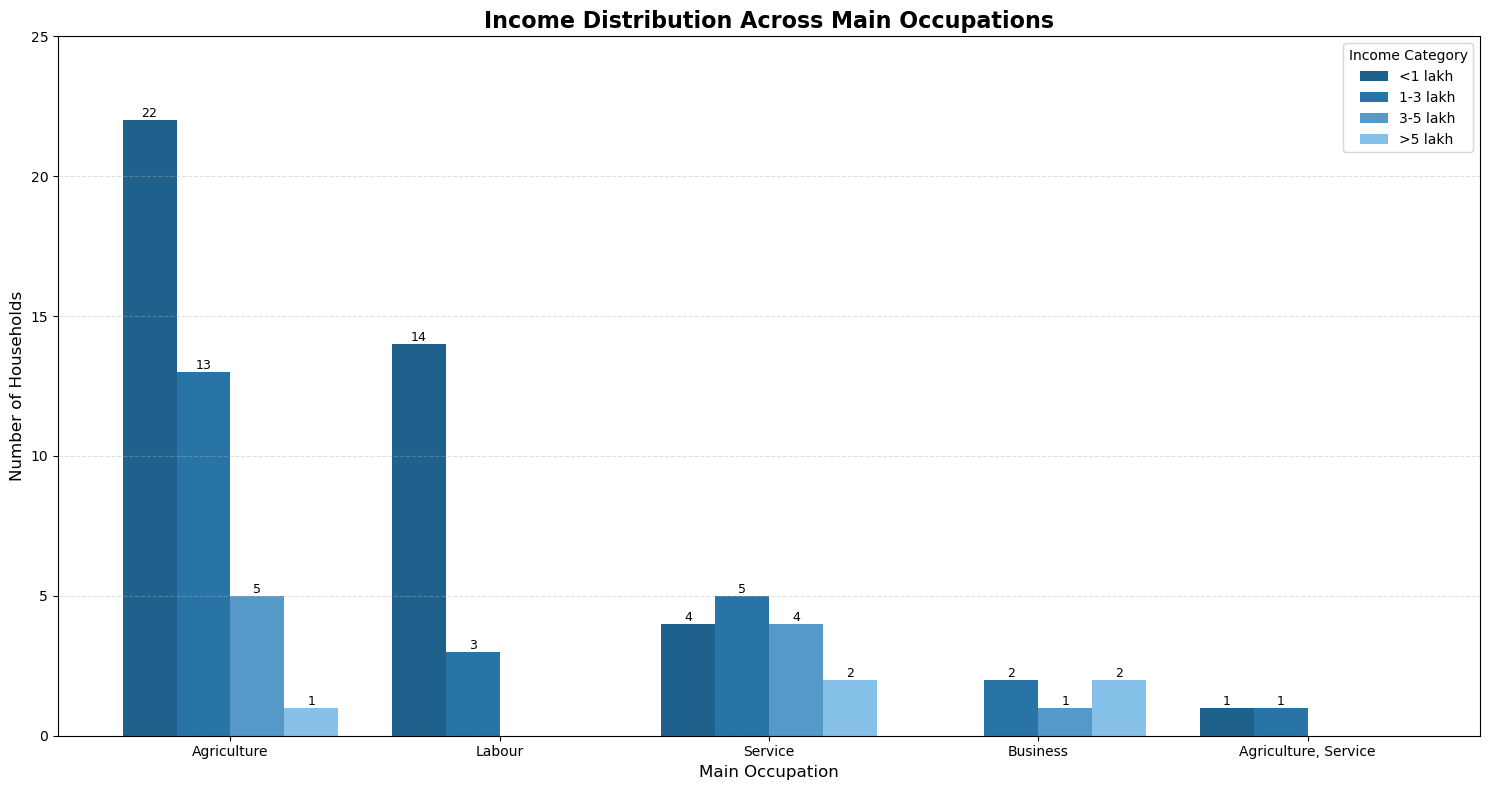

In [19]:
plt.figure(figsize=(15,8))

x = np.arange(len(income_occupation.index))
width = 0.2
colors = ['#1F618D', '#2874A6', '#5499C7', '#85C1E9']

for i, income_cat in enumerate(order):
    bars = plt.bar(x + i*width,
                   income_occupation[income_cat],
                   width,
                   label=income_cat,
                   color=colors[i])
    
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            plt.text(bar.get_x() + bar.get_width()/2,
                     height,
                     int(height),
                     ha='center',
                     va='bottom',
                     fontsize=9)

plt.xticks(x + width*1.5, income_occupation.index)
plt.xlabel("Main Occupation", fontsize=12)
plt.ylabel("Number of Households", fontsize=12)
plt.title("Income Distribution Across Main Occupations", fontsize=16, fontweight='bold')

plt.legend(title="Income Category")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.ylim(0, income_occupation.values.max()+3)
plt.tight_layout()
plt.show()

In [20]:
avg_family_size = df['Total Family Members'].mean()
print("Average Family Size:", round(avg_family_size,2))

Average Family Size: 5.23


# 3.Social Inclusion Profile

In [21]:
df['Social Category'].value_counts()

Social Category
General            51
Scheduled Caste    23
OBC                 9
Scheduled Tribe     1
Name: count, dtype: int64

In [22]:
social_category = df['Social Category'].value_counts()
per_social_category = round((social_category/social_category.sum())*100,2)
per_social_category

Social Category
General            60.71
Scheduled Caste    27.38
OBC                10.71
Scheduled Tribe     1.19
Name: count, dtype: float64

In [23]:
round(pd.crosstab(df['Social Category'], df['Livelihood Schemes   [PM-KISAN]'], normalize='index') * 100,2)

Livelihood Schemes [PM-KISAN],Applied,Aware,Not Aware
Social Category,,,
General,1.96,49.02,49.02
OBC,0.00,33.33,66.67
Scheduled Caste,4.35,34.78,60.87
Scheduled Tribe,0.00,0.00,100.00


In [24]:
social = df['Social Category'].value_counts()
social = social.sort_values(ascending=False)
total = social.sum()

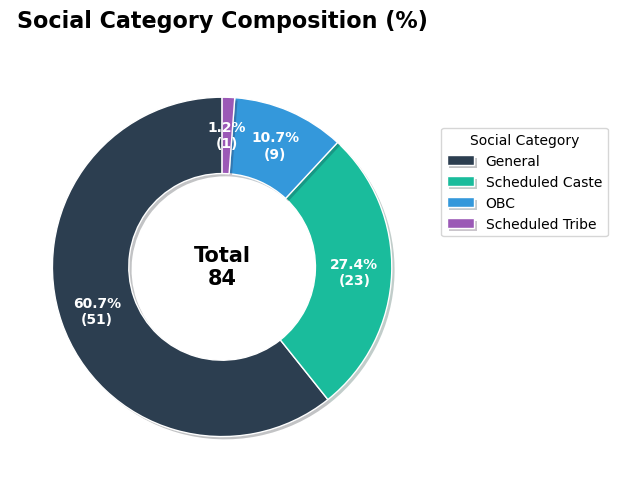

In [25]:
colors = ['#2C3E50', '#1ABC9C', '#3498DB', '#9B59B6']
plt.figure(figsize=(10,5))

wedges, texts, autotexts = plt.pie(social.values, startangle=90, colors=colors, wedgeprops=dict(width=0.45, edgecolor='white'),
                                   pctdistance=0.78, autopct=lambda p: f"{p:.1f}%\n({int(round(p*total/100))})")
for wedge in wedges:
    wedge.set_path_effects([
        pe.SimplePatchShadow(offset=(2, -2), alpha=0.25),
        pe.Normal()])

for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

plt.text(0, 0, f"Total\n{total}", ha='center', va='center', fontsize=15, fontweight='bold')
plt.title("Social Category Composition (%)", fontsize=16, fontweight='bold', pad=20)
plt.legend(wedges, social.index, title="Social Category", loc="center left", bbox_to_anchor=(1,0.7))
plt.tight_layout()
plt.show()

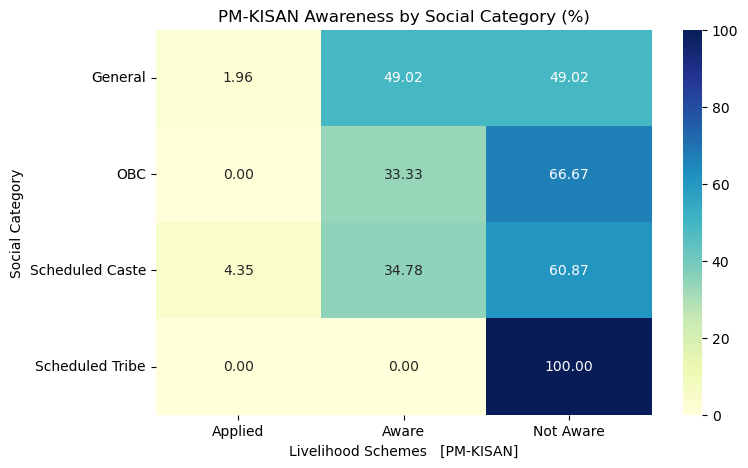

In [26]:
scheme_equity = pd.crosstab(
    df['Social Category'],
    df['Livelihood Schemes   [PM-KISAN]'],
    normalize='index') * 100

plt.figure(figsize=(8,5))
sns.heatmap(scheme_equity,annot=True, cmap="YlGnBu", fmt=".2f")

plt.title("PM-KISAN Awareness by Social Category (%)")
plt.show()

# Health & Nutrition Indicators Framework

# Institutional Delivery Rate

In [27]:
inst_delivery = df['Last delivery was institutional  (in any hospital)'].value_counts(normalize=True) * 100
round(inst_delivery,2)

Last delivery was institutional  (in any hospital)
YES    52.38
No     47.62
Name: proportion, dtype: float64

# Immunization Coverage (0–5 Years)

In [28]:
immunization = df['Immunization status of children (0-5)'].value_counts()
immunization

Immunization status of children (0-5)
Fully            59
Not immunised    16
Partially         9
Name: count, dtype: int64

In [29]:
immunization = df['Immunization status of children (0-5)'].value_counts(normalize=True) * 100
round(immunization,2)

Immunization status of children (0-5)
Fully            70.24
Not immunised    19.05
Partially        10.71
Name: proportion, dtype: float64

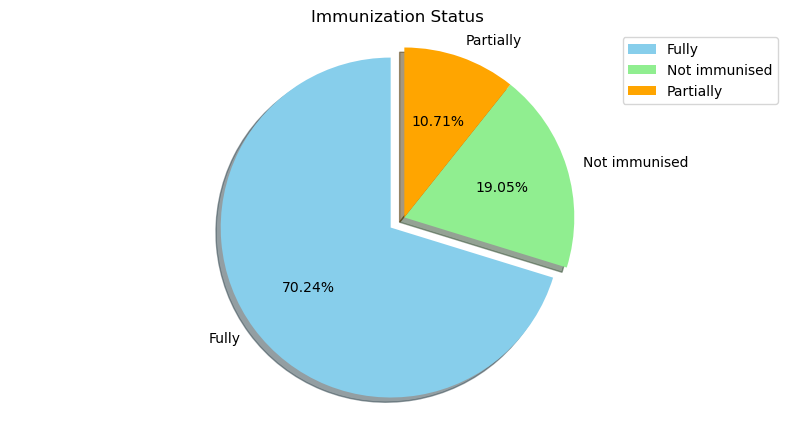

In [30]:
plt.figure(figsize=(10,5))
plt.pie(immunization.values, labels=immunization.index, autopct='%1.2f%%', startangle=90, explode = [0.1, 0, 0], shadow=True,
       colors=['skyblue','lightgreen','orange'])
plt.title("Immunization Status")
plt.axis('equal')
plt.legend()
plt.show()

# Healthcare Accessibility Gap

In [31]:
health_dist = df['Distance to nearest health facility'].value_counts()
health_dist

Distance to nearest health facility
1-5 km    43
>5 km     21
<1 km     20
Name: count, dtype: int64

In [32]:
health_dist = round(df['Distance to nearest health facility'].value_counts(normalize=True) * 100,2)
health_dist

Distance to nearest health facility
1-5 km    51.19
>5 km     25.00
<1 km     23.81
Name: proportion, dtype: float64

In [33]:
order = ['<1 km', '1-5 km', '>5 km']
health_dist = health_dist[order]

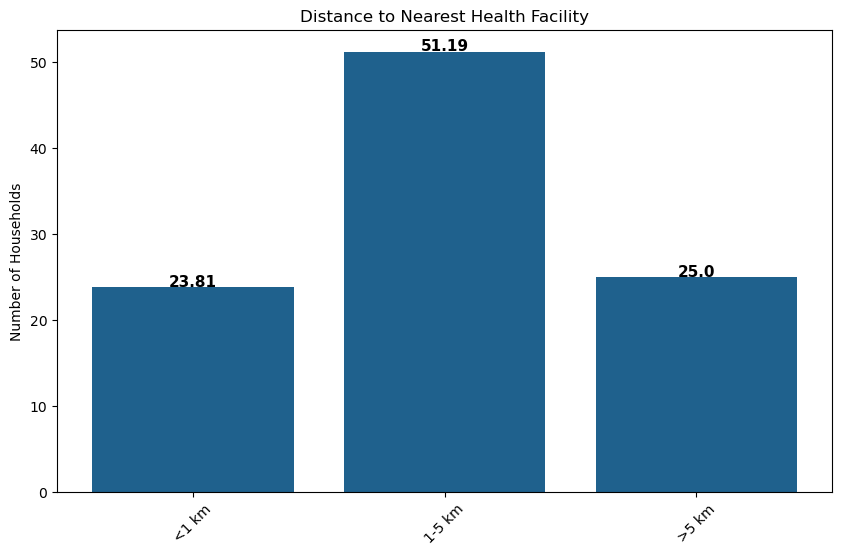

In [34]:
plt.figure(figsize=(10,6))
bars = plt.bar(health_dist.index, health_dist.values, color='#1F618D')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            bar.get_height(),
            ha='center',
            fontsize=11,
            fontweight='bold')
plt.title("Distance to Nearest Health Facility")
plt.ylabel("Number of Households")
plt.xticks(rotation=45)
plt.show()

# Disease Prevalence Rate

In [35]:
df['Common diseases'].value_counts()

Common diseases
BP                 18
Diabetes           11
BP, Diabetes        9
BP, Respiratory     2
BP, TB              1
TB, None            1
BP, None            1
TB, Respiratory     1
Name: count, dtype: int64

In [36]:
diseases_rate = df['Common diseases'].notna().mean() * 100
print(f'Diseases Rate = {round(diseases_rate,2)}%')

Diseases Rate = 52.38%


In [37]:
common_diseases = df['Common diseases'].str.split(',').explode().str.strip()

In [38]:
common_diseases_count = common_diseases.value_counts()
common_diseases_count

Common diseases
BP             31
Diabetes       20
TB              3
Respiratory     3
None            2
Name: count, dtype: int64

In [39]:
common_diseases_percentage = round((common_diseases_count/common_diseases_count.sum())*100,2)
common_diseases_percentage

Common diseases
BP             52.54
Diabetes       33.90
TB              5.08
Respiratory     5.08
None            3.39
Name: count, dtype: float64

# Scheme Awareness & Utilization (Health)

In [40]:
pmjay = round(df['Health Schemes   [Ayushman Bharat (PM-JAY)]'].value_counts(normalize=True) * 100,2)
pmjay

Health Schemes   [Ayushman Bharat (PM-JAY)]
Aware        33.33
Not aware    33.33
Availed      20.24
Applied      13.10
Name: proportion, dtype: float64

In [41]:
jsy = round(df['Health Schemes   [Janani Suraksha Yojana]'].value_counts(normalize=True) * 100,2)
jsy

Health Schemes   [Janani Suraksha Yojana]
Not aware    63.10
Aware        32.14
Availed       4.76
Name: proportion, dtype: float64

# Education & Digital Literacy Indicators

# 1. Household Literacy Rate

In [42]:
literacy = df['Literacy status of household'].value_counts()
literacy

Literacy status of household
Partially literate    44
All literate          35
Mostly illiterate      5
Name: count, dtype: int64

In [43]:
literacy_percent = round(df['Literacy status of household'].value_counts(normalize=True) * 100,2)
literacy_percent

Literacy status of household
Partially literate    52.38
All literate          41.67
Mostly illiterate      5.95
Name: proportion, dtype: float64

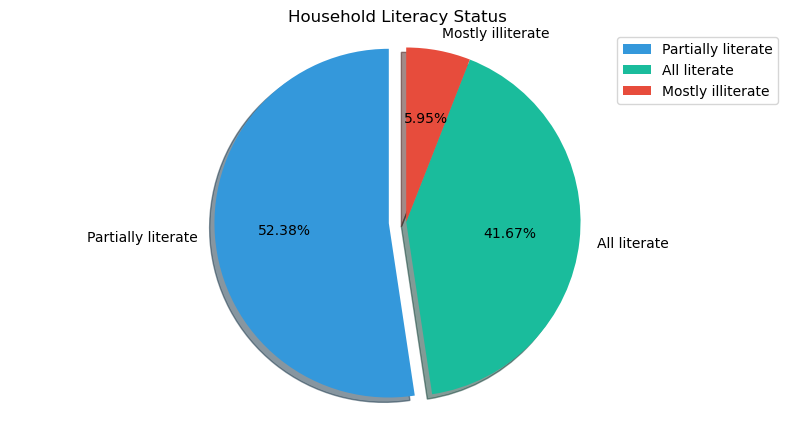

In [44]:
plt.figure(figsize=(10,5))
plt.pie(literacy_percent.values, labels=literacy_percent.index, autopct='%1.2f%%', startangle=90, colors=['#3498DB','#1ABC9C','#E74C3C'], shadow=True,
       explode=[0.1,0,0])
plt.title("Household Literacy Status")
plt.axis('equal')
plt.legend()
plt.show()

# 2. School Dropout Rate

In [45]:
dropout = df['School dropout cases  in the household'].value_counts()
dropout

School dropout cases  in the household
NO        69
YES       13
Partia     2
Name: count, dtype: int64

In [46]:
dropout_percent = round(df['School dropout cases  in the household'].value_counts(normalize=True) * 100,2)
dropout_percent

School dropout cases  in the household
NO        82.14
YES       15.48
Partia     2.38
Name: proportion, dtype: float64

In [47]:
reasons = df['Reason for dropout'].value_counts()
reasons

Reason for dropout
Financial           26
Migration           18
Lack of interest    12
Domestic work        6
Name: count, dtype: int64

In [48]:
reasons_percent = round(df['Reason for dropout'].value_counts(normalize=True)*100,2)
reasons_percent

Reason for dropout
Financial           41.94
Migration           29.03
Lack of interest    19.35
Domestic work        9.68
Name: proportion, dtype: float64

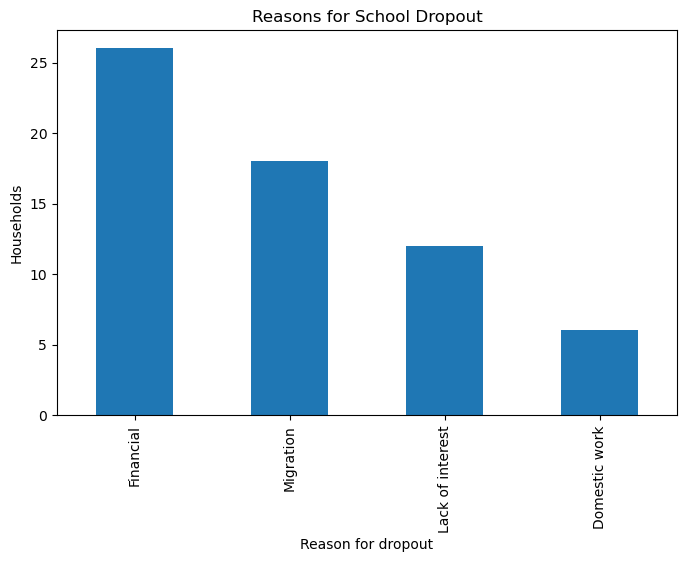

In [49]:
plt.figure(figsize=(8,5))
reasons.plot(kind='bar')
plt.title("Reasons for School Dropout")
plt.ylabel("Households")
plt.xticks(rotation=90)
plt.show()

In [50]:
reasons_strip = df['Reason for dropout'].str.split(',').explode().str.strip()

In [51]:
reasons_value = reasons_strip.value_counts()
reasons_value

Reason for dropout
Financial           26
Migration           18
Lack of interest    12
Domestic work        6
Name: count, dtype: int64

In [52]:
reasons_percentage = round((reasons_value/reasons_value.sum())*100,2)
reasons_percentage

Reason for dropout
Financial           41.94
Migration           29.03
Lack of interest    19.35
Domestic work        9.68
Name: count, dtype: float64

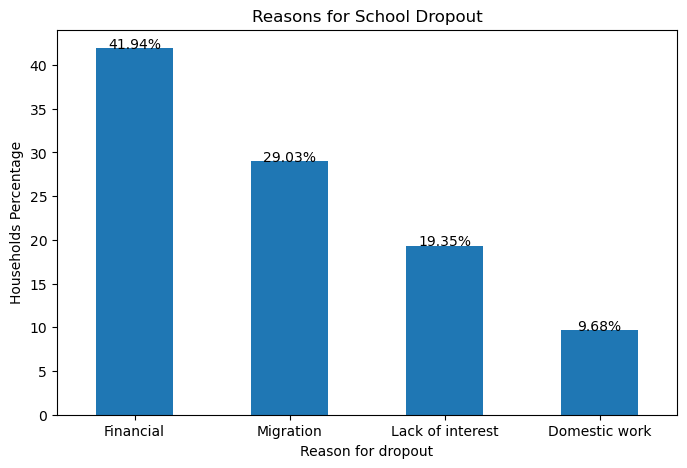

In [53]:
plt.figure(figsize=(8,5))
reasons_percentage.plot(kind='bar')
for i, v in enumerate(reasons_percentage.values):
    plt.text(i, v, f'{v:.2f}%', ha='center')
plt.title("Reasons for School Dropout")
plt.ylabel("Households Percentage")
plt.xticks(rotation=0)
plt.show()

# 3. Digital Divide Index

In [54]:
digital = df['Access to digital devices'].value_counts()
digital

Access to digital devices
Smartphone            69
Smartphone, Laptop     9
Laptop                 2
Name: count, dtype: int64

In [55]:
digital_percent = round(df['Access to digital devices'].value_counts(normalize=True) * 100,2)
digital_percent

Access to digital devices
Smartphone            86.25
Smartphone, Laptop    11.25
Laptop                 2.50
Name: proportion, dtype: float64

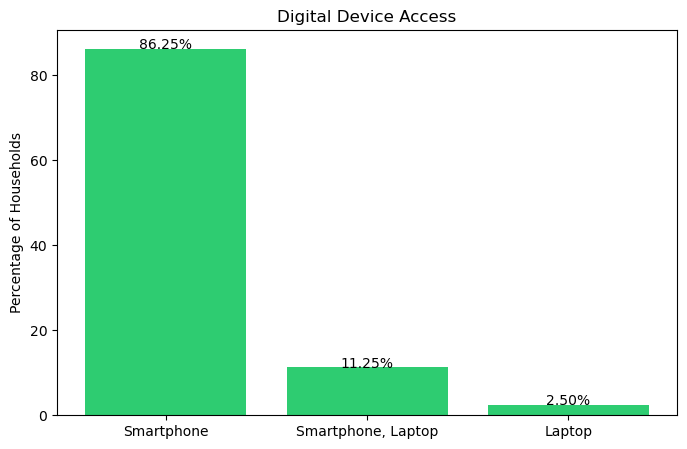

In [56]:
plt.figure(figsize=(8,5))
plt.bar(digital_percent.index, digital_percent.values, color='#2ECC71')
for i,v in enumerate(digital_percent.values):
    plt.text(i, v, f"{v:.2f}%", ha='center')

plt.title("Digital Device Access")
plt.ylabel("Percentage of Households")
plt.show()

In [57]:
digital_values = df['Access to digital devices'].str.split(',').explode().str.strip()

In [58]:
digital_count = digital_values.value_counts()
digital_count

Access to digital devices
Smartphone    78
Laptop        11
Name: count, dtype: int64

In [59]:
digital_percentage = round((digital_count/digital_count.sum())*100,2)
digital_percentage

Access to digital devices
Smartphone    87.64
Laptop        12.36
Name: count, dtype: float64

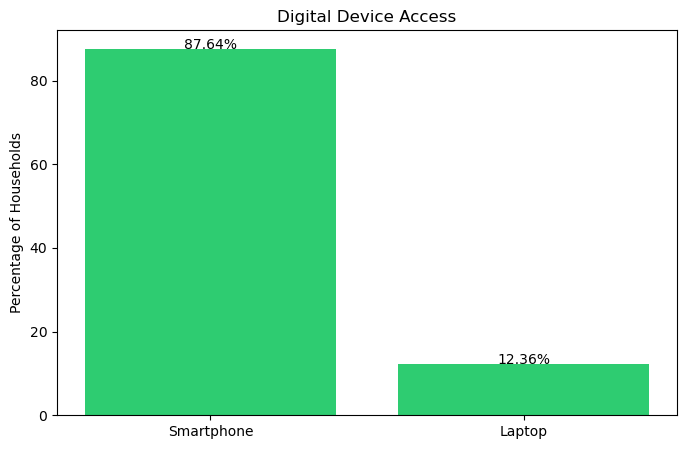

In [60]:
plt.figure(figsize=(8,5))
plt.bar(digital_percentage.index, digital_percentage.values, color='#2ECC71')
for i,v in enumerate(digital_percentage.values):
    plt.text(i, v, f"{v:.2f}%", ha='center')

plt.title("Digital Device Access")
plt.ylabel("Percentage of Households")
plt.show()

# 4. Gender Gap in Higher Education

In [61]:
girls_edu = df['Girls continuing education beyond Class X'].value_counts()
girls_edu

Girls continuing education beyond Class X
YES    54
No     30
Name: count, dtype: int64

In [62]:
girls_edu_percent = round(df['Girls continuing education beyond Class X'].value_counts(normalize=True)*100,2)
girls_edu_percent

Girls continuing education beyond Class X
YES    64.29
No     35.71
Name: proportion, dtype: float64

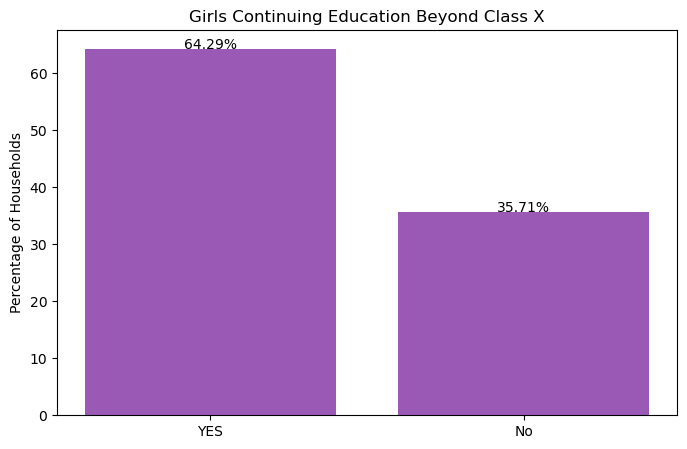

In [63]:
plt.figure(figsize=(8,5))
plt.bar(girls_edu_percent.index, girls_edu_percent.values, color='#9B59B6')

for i,v in enumerate(girls_edu_percent.values):
    plt.text(i, v, f"{v:.2f}%", ha='center')

plt.title("Girls Continuing Education Beyond Class X")
plt.ylabel("Percentage of Households")
plt.show()

# 5. Remedial Support Demand

In [64]:
remedial = df['Need for remedial/coaching support'].value_counts()
remedial

Need for remedial/coaching support
No     47
Yes    37
Name: count, dtype: int64

In [65]:
remedial_percent = round(df['Need for remedial/coaching support'].value_counts(normalize=True)*100,2)
remedial_percent

Need for remedial/coaching support
No     55.95
Yes    44.05
Name: proportion, dtype: float64

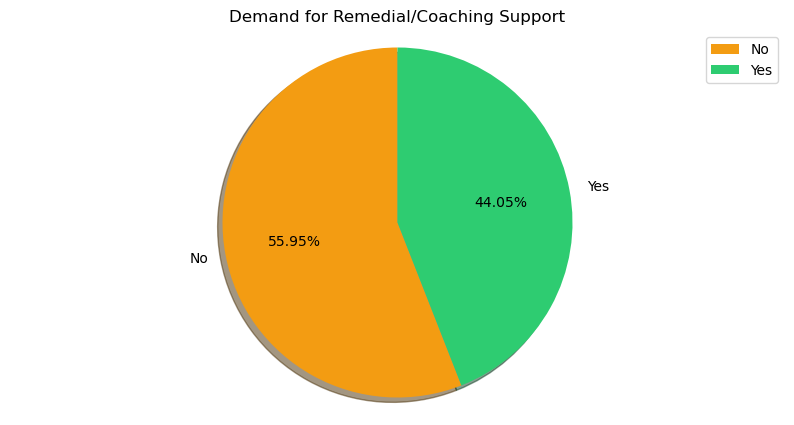

In [66]:
plt.figure(figsize=(10,5))
plt.pie(remedial_percent.values, labels=remedial_percent.index, autopct='%1.2f%%', colors=['#F39C12','#2ECC71'], startangle=90, shadow=True)
plt.title("Demand for Remedial/Coaching Support")
plt.axis('equal')
plt.legend()
plt.show()

# Water, Sanitation & Hygiene (WASH) Indicators

# 1. Safe Drinking Water Access

In [67]:
water_source = df['Source of drinking water'].value_counts()
water_source

Source of drinking water
Tap                66
Tap, Tanker         7
Tap, Hand pump      4
Tap, Well           2
Tanker              2
Hand pump           1
Well                1
Hand pump, Well     1
Name: count, dtype: int64

In [68]:
water_source_split = df['Source of drinking water'].str.split(',').explode().str.strip()

In [69]:
water_source_count = water_source_split.value_counts()
water_source_count

Source of drinking water
Tap          79
Tanker        9
Hand pump     6
Well          4
Name: count, dtype: int64

In [70]:
water_source_percentage = round((water_source_count/water_source_count.sum())*100,2)
water_source_percentage

Source of drinking water
Tap          80.61
Tanker        9.18
Hand pump     6.12
Well          4.08
Name: count, dtype: float64

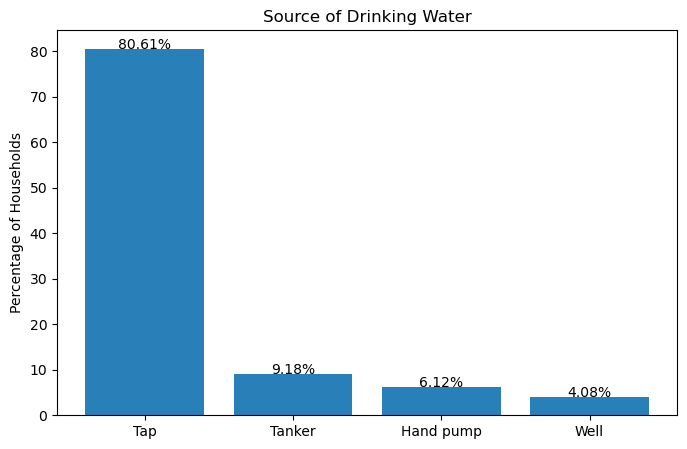

In [71]:
plt.figure(figsize=(8,5))
bars = plt.bar(water_source_percentage.index, water_source_percentage.values, color='#2980B9')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.2f}%",
             ha='center')

plt.title("Source of Drinking Water")
plt.ylabel("Percentage of Households")
plt.xticks()
plt.show()

In [72]:
water_quality = df['Quality of drinking water'].value_counts(normalize=True) * 100
round(water_quality,2)

Quality of drinking water
Good       83.33
Average    15.48
Poor        1.19
Name: proportion, dtype: float64

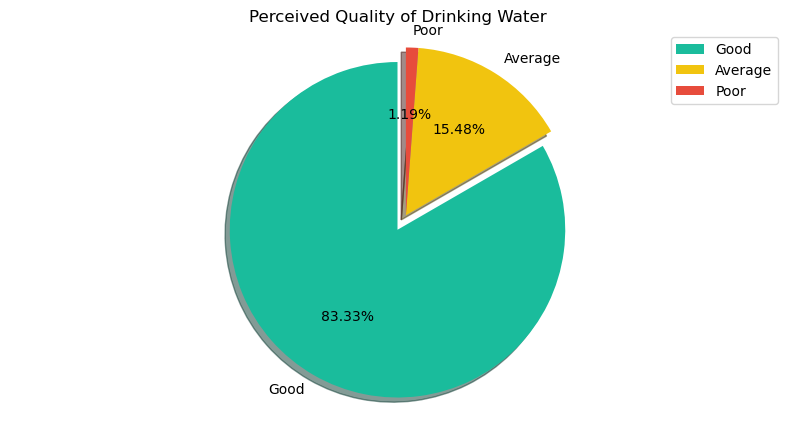

In [73]:
plt.figure(figsize=(10,5))
plt.pie(water_quality.values, labels=water_quality.index, autopct='%1.2f%%', explode=[0.1,0,0], colors=['#1ABC9C','#F1C40F','#E74C3C'], 
        startangle=90, shadow=True)
plt.title("Perceived Quality of Drinking Water")
plt.axis('equal')
plt.legend()
plt.show()

# 2. Sanitation Coverage

In [74]:
toilet = df['Toilet availability'].value_counts(normalize=True) * 100
round(toilet,2)

Toilet availability
YES    98.81
NO      1.19
Name: proportion, dtype: float64

In [75]:
handwash = df['Handwashing with soap'].value_counts(normalize=True) * 100
round(handwash,2)

Handwashing with soap
Always       96.43
Sometimes     2.38
Rarely        1.19
Name: proportion, dtype: float64

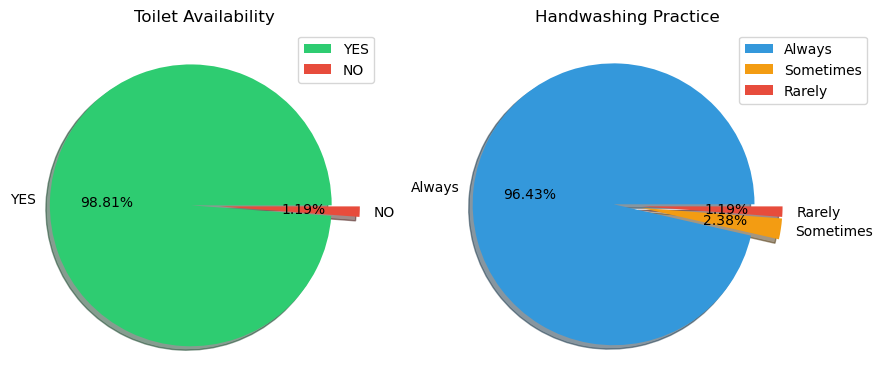

In [76]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.pie(toilet.values, labels=toilet.index, autopct='%1.2f%%',colors=['#2ECC71','#E74C3C'], explode=[0.1,0.1], shadow=True)
plt.title("Toilet Availability")
plt.legend()

plt.subplot(1,2,2)
plt.pie(handwash.values, labels=handwash.index, autopct='%1.2f%%',colors=['#3498DB','#F39C12','#E74C3C'], explode=[0.1,0.1,0.1], shadow=True)
plt.title("Handwashing Practice")
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
plt.show()

# 3. Waste Management Efficiency

In [77]:
waste = df['Solid waste disposal method'].value_counts()
waste

Solid waste disposal method
Open dumping                  73
Burning                        5
Open dumping, Burning          4
Door-to-door                   1
Door-to-door, Open dumping     1
Name: count, dtype: int64

In [78]:
waste_percent = round(df['Solid waste disposal method'].value_counts(normalize=True)*100,2)
waste_percent

Solid waste disposal method
Open dumping                  86.90
Burning                        5.95
Open dumping, Burning          4.76
Door-to-door                   1.19
Door-to-door, Open dumping     1.19
Name: proportion, dtype: float64

In [79]:
waste_split = df['Solid waste disposal method'].str.split(',').explode().str.strip()

In [80]:
waste_split_count = waste_split.value_counts()
waste_split_count

Solid waste disposal method
Open dumping    78
Burning          9
Door-to-door     2
Name: count, dtype: int64

In [81]:
waste_split_percentage = round((waste_split_count / waste_split_count.sum()) * 100, 2)
waste_split_percentage

Solid waste disposal method
Open dumping    87.64
Burning         10.11
Door-to-door     2.25
Name: count, dtype: float64

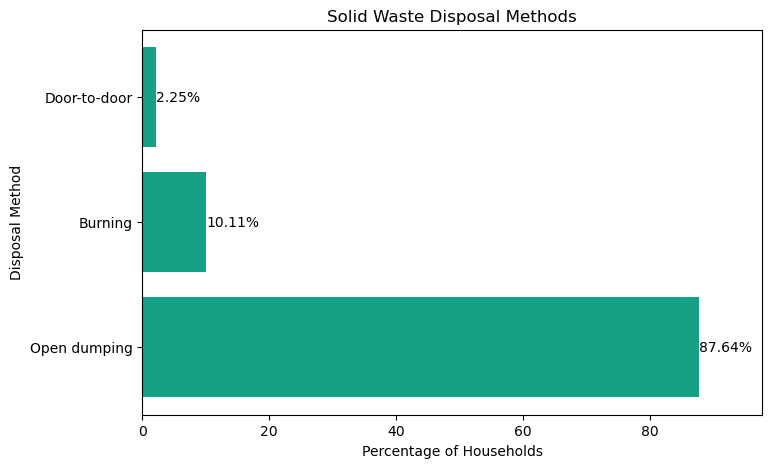

In [82]:
plt.figure(figsize=(8,5))
bars = plt.barh(waste_split_percentage.index, waste_split_percentage.values, color='#16A085')
for bar in bars:
    plt.text(bar.get_width(),
             bar.get_y() + bar.get_height()/2,
             f"{bar.get_width():.2f}%",
             va='center')

plt.title("Solid Waste Disposal Methods")
plt.xlabel("Percentage of Households")
plt.ylabel("Disposal Method")
plt.xlim(0,waste_split_percentage.values.max()+10)
plt.show()

# 4.Open Defecation Status

In [83]:
od = df['Open defecation in village'].value_counts(normalize=True) * 100
round(od,2)

Open defecation in village
No     51.19
Yes    48.81
Name: proportion, dtype: float64

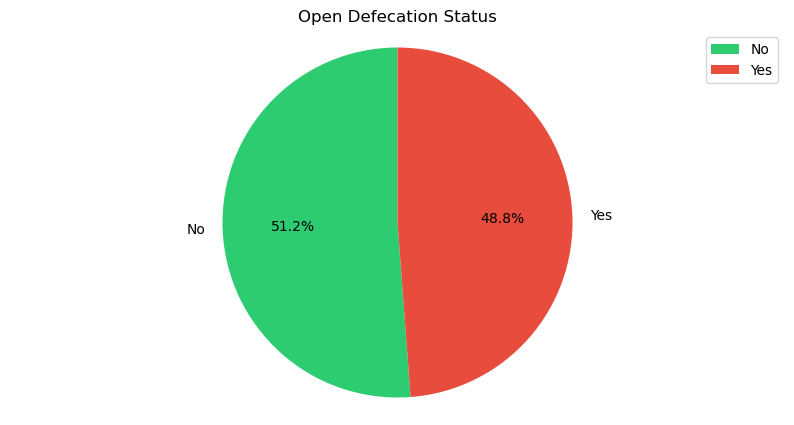

In [84]:
plt.figure(figsize=(10,5))
plt.pie(od.values, labels=od.index, autopct='%1.1f%%', colors=['#2ECC71','#E74C3C'], startangle=90)
plt.title("Open Defecation Status")
plt.axis('equal')
plt.legend()
plt.show()

# Environmental & Disaster Resilience Indicators

# 1. Environmental Stress Index

In [85]:
env_stress = df['Major environmental problems'].value_counts()
env_stress

Major environmental problems
Solid waste                                                 20
Flooding                                                    18
Groundwater depletion                                       14
Crop residue burning                                        14
Groundwater depletion, Flooding, Solid waste                 3
Groundwater depletion, Soil degradation, Solid waste         3
Groundwater depletion, Crop residue burning                  2
Crop residue burning, Solid waste                            2
Flooding, Solid waste                                        2
Soil degradation                                             1
Groundwater depletion, Crop residue burning, Solid waste     1
Soil degradation, Solid waste                                1
Groundwater depletion, Flooding                              1
Groundwater depletion, Solid waste                           1
Crop residue burning, Soil degradation                       1
Name: count, dtype: int64

In [86]:
env_stress = df['Major environmental problems'].str.split(',').explode().str.strip()

In [87]:
env_stress_counts = env_stress.value_counts()
env_stress_counts

Major environmental problems
Solid waste              33
Groundwater depletion    25
Flooding                 24
Crop residue burning     20
Soil degradation          6
Name: count, dtype: int64

In [88]:
percentage_env_stress_counts = round(env_stress.value_counts(normalize=True)*100,2)
percentage_env_stress_counts

Major environmental problems
Solid waste              30.56
Groundwater depletion    23.15
Flooding                 22.22
Crop residue burning     18.52
Soil degradation          5.56
Name: proportion, dtype: float64

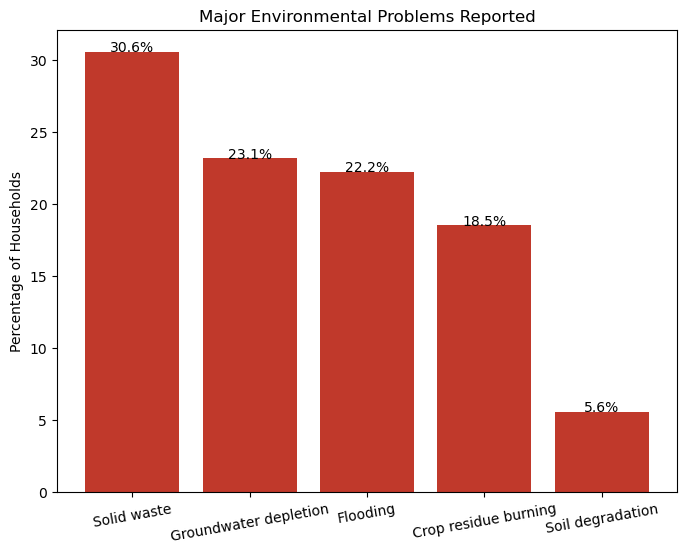

In [89]:
plt.figure(figsize=(8,6))
bars = plt.bar(percentage_env_stress_counts.index, percentage_env_stress_counts.values, color='#C0392B')
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.1f}%",
             ha='center')
plt.title("Major Environmental Problems Reported")
plt.ylabel("Percentage of Households")
plt.xticks(rotation=10)
plt.show()

# 2. Renewable Energy Adoption

In [90]:
df['Renewable energy usage'].value_counts()

Renewable energy usage
Solar lights                 15
Solar lights, Solar pumps     1
Biogas                        1
Name: count, dtype: int64

In [91]:
renewable = df['Renewable energy usage'].str.split(',').explode().str.strip()

In [92]:
renewable_counts = renewable.value_counts()
renewable_counts

Renewable energy usage
Solar lights    16
Solar pumps      1
Biogas           1
Name: count, dtype: int64

In [93]:
percentage_renewable_counts = round(renewable.value_counts(normalize=True)*100,2)
percentage_renewable_counts

Renewable energy usage
Solar lights    88.89
Solar pumps      5.56
Biogas           5.56
Name: proportion, dtype: float64

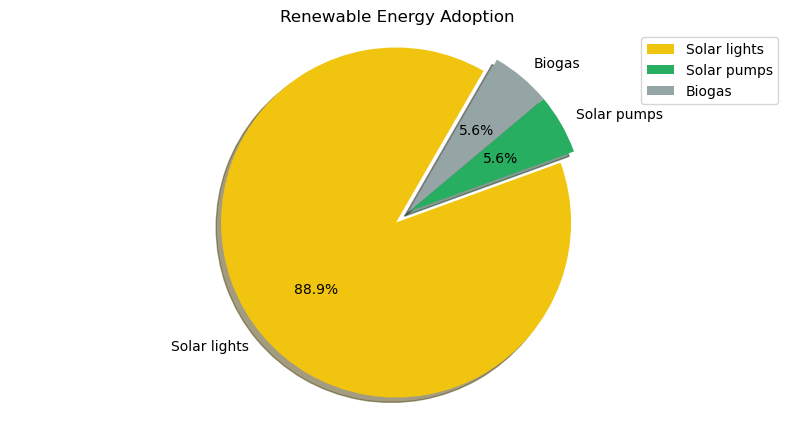

In [94]:
plt.figure(figsize=(10,5))
plt.pie(percentage_renewable_counts.values, labels=percentage_renewable_counts.index, autopct='%1.1f%%', startangle=60, shadow = True,
        colors=['#F1C40F','#27AE60','#95A5A6', '#C0392B'], explode=[0.1,0,0])
plt.title("Renewable Energy Adoption")
plt.legend(loc='upper right')
plt.axis('equal')
plt.show()

# 3. Disaster Vulnerability Score

In [95]:
df['Disaster vulnerability'].value_counts()

Disaster vulnerability
Flood              22
Drought             3
Flood, Heatwave     2
Heatwave            2
Name: count, dtype: int64

In [96]:
disaster = df['Disaster vulnerability'].str.split(',').explode().str.strip()

In [97]:
disaster_count = disaster.value_counts()
disaster_count

Disaster vulnerability
Flood       24
Heatwave     4
Drought      3
Name: count, dtype: int64

In [98]:
disaster_percent = round(disaster.value_counts(normalize=True)*100,2)
disaster_percent

Disaster vulnerability
Flood       77.42
Heatwave    12.90
Drought      9.68
Name: proportion, dtype: float64

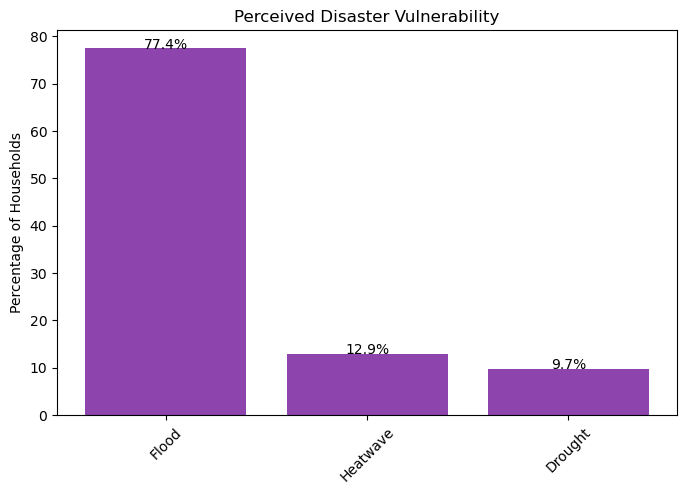

In [99]:
plt.figure(figsize=(8,5))
bars = plt.bar(disaster_percent.index, disaster_percent.values, color='#8E44AD')
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.1f}%",
             ha='center')
plt.title("Perceived Disaster Vulnerability")
plt.ylabel("Percentage of Households")
plt.xticks(rotation=45)
plt.show()

# 4. Pond Health Status

In [100]:
pond_condition = df['Condition of pond'].value_counts()
pond_condition

Condition of pond
Highly polluted       69
Partially polluted    10
Clean                  5
Name: count, dtype: int64

In [101]:
pond_percent = round(df['Condition of pond'].value_counts(normalize=True)*100,2)
pond_percent

Condition of pond
Highly polluted       82.14
Partially polluted    11.90
Clean                  5.95
Name: proportion, dtype: float64

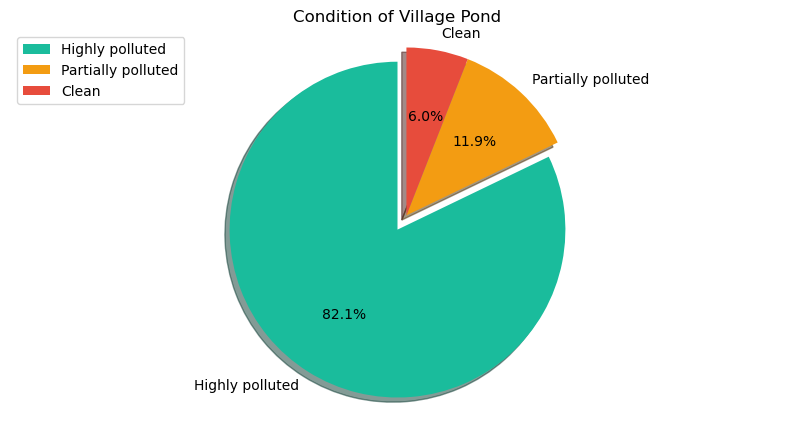

In [102]:
plt.figure(figsize=(10,5))
plt.pie(pond_percent.values, labels=pond_percent.index, autopct='%1.1f%%', colors=['#1ABC9C','#F39C12','#E74C3C'], startangle=90, explode=[0.1,0,0], 
       shadow=True)
plt.title("Condition of Village Pond")
plt.axis('equal')
plt.legend()
plt.show()

# Women Empowerment & Governance Indicators

# Female Labour Force Participation

In [103]:
female_lfp = df['Household women  engaged in income activity'].value_counts()
female_lfp

Household women  engaged in income activity
No     67
Yes    17
Name: count, dtype: int64

In [104]:
percentage_female_lfp = round(df['Household women  engaged in income activity'].value_counts(normalize=True)*100,2)
percentage_female_lfp

Household women  engaged in income activity
No     79.76
Yes    20.24
Name: proportion, dtype: float64

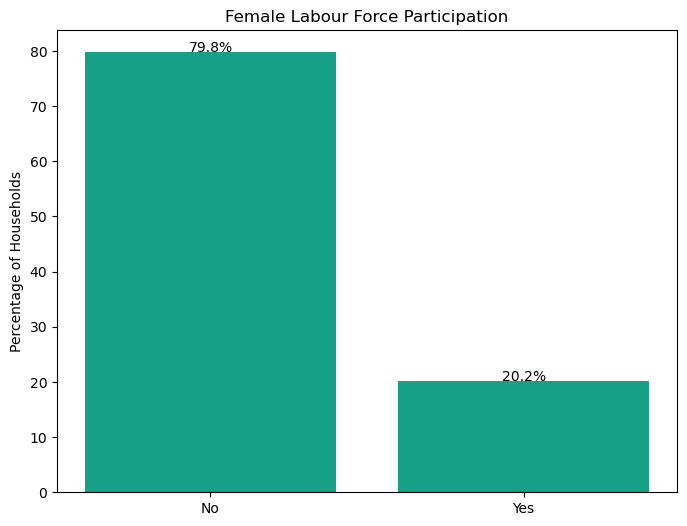

In [105]:
plt.figure(figsize=(8,6))
bars = plt.bar(percentage_female_lfp.index, percentage_female_lfp.values, color='#16A085')

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.1f}%",
             ha='center')

plt.title("Female Labour Force Participation")
plt.ylabel("Percentage of Households")
plt.show()

# Women Bank Account Ownership

In [106]:
women_bank = df['Bank account in woman’s name'].value_counts()
women_bank

Bank account in woman’s name
Yes    66
No     18
Name: count, dtype: int64

In [107]:
percentage_women_bank = round(df['Bank account in woman’s name'].value_counts(normalize=True)*100,2)
percentage_women_bank

Bank account in woman’s name
Yes    78.57
No     21.43
Name: proportion, dtype: float64

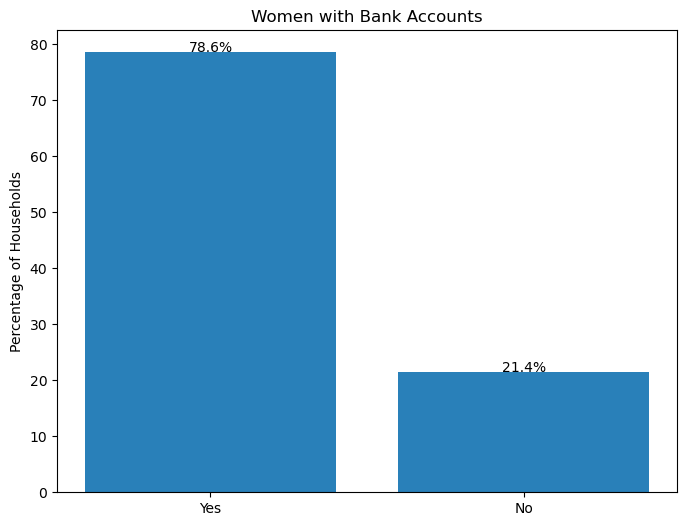

In [108]:
plt.figure(figsize=(8,6))
bars = plt.bar(percentage_women_bank.index, percentage_women_bank.values, color='#2980B9')
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.1f}%",
             ha='center')
plt.title("Women with Bank Accounts")
plt.ylabel("Percentage of Households")
plt.show()

# SHG Membership

In [109]:
shg = df['SHG membership'].value_counts()
shg

SHG membership
No     80
Yes     4
Name: count, dtype: int64

In [110]:
percentage_shg = round(df['SHG membership'].value_counts(normalize=True)*100,2)
percentage_shg

SHG membership
No     95.24
Yes     4.76
Name: proportion, dtype: float64

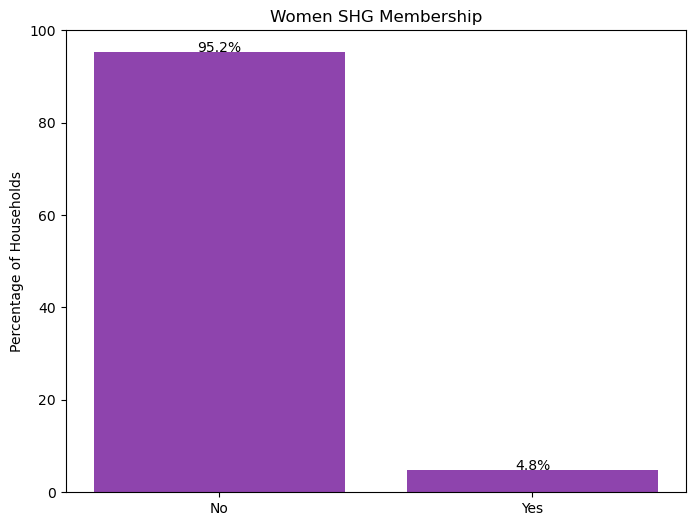

In [111]:
plt.figure(figsize=(8,6))
bars = plt.bar(percentage_shg.index, percentage_shg.values, color='#8E44AD')
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.1f}%",
             ha='center')
plt.title("Women SHG Membership")
plt.ylabel("Percentage of Households")
plt.show()

# Governance Awareness (Gram Sabha)

In [112]:
gram_sabha = df['Awareness about Gram Sabha meetings'].value_counts()
gram_sabha

Awareness about Gram Sabha meetings
Yes    54
No     30
Name: count, dtype: int64

In [113]:
percentage_gram_sabha = round(df['Awareness about Gram Sabha meetings'].value_counts(normalize=True)*100,2)
percentage_gram_sabha

Awareness about Gram Sabha meetings
Yes    64.29
No     35.71
Name: proportion, dtype: float64

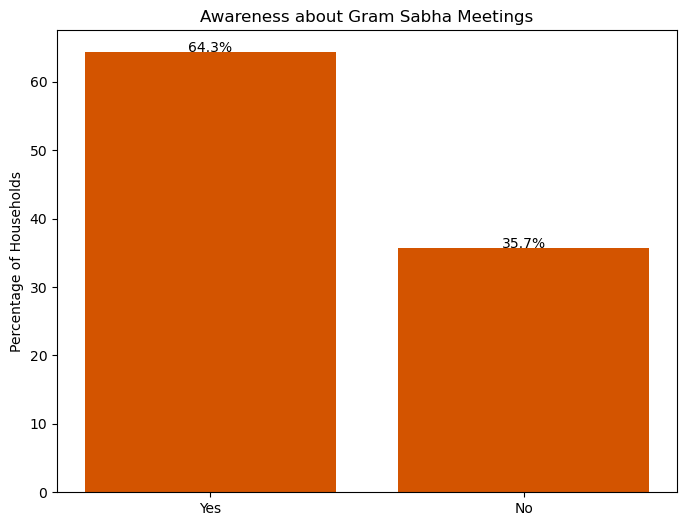

In [114]:
plt.figure(figsize=(8,6))
bars = plt.bar(percentage_gram_sabha.index, percentage_gram_sabha.values, color='#D35400')
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.1f}%",
             ha='center')
plt.title("Awareness about Gram Sabha Meetings")
plt.ylabel("Percentage of Households")
plt.show()

# Women Decision-Making Power

In [115]:
decision = df['Role of women in decision-making'].value_counts()
decision

Role of women in decision-making
Moderate    57
High        16
Low         11
Name: count, dtype: int64

In [116]:
percentage_decision = round(df['Role of women in decision-making'].value_counts(normalize=True)*100,2)
percentage_decision

Role of women in decision-making
Moderate    67.86
High        19.05
Low         13.10
Name: proportion, dtype: float64

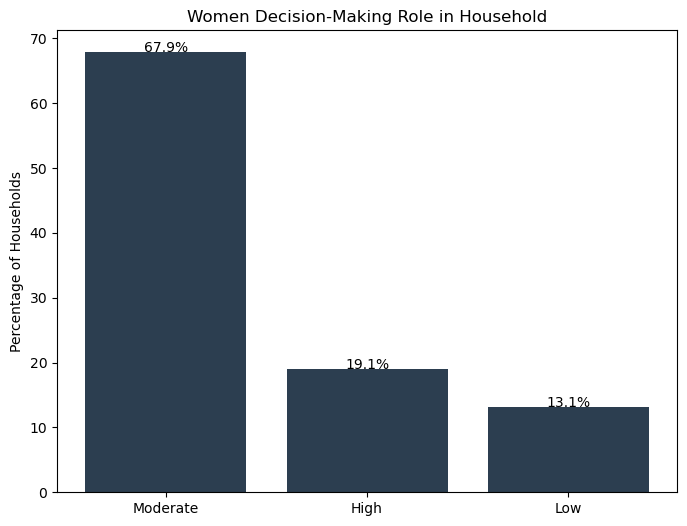

In [117]:
plt.figure(figsize=(8,6))
bars = plt.bar(percentage_decision.index, percentage_decision.values, color='#2C3E50')
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.1f}%",
             ha='center')
plt.title("Women Decision-Making Role in Household")
plt.ylabel("Percentage of Households")
plt.show()

# Strategie Gap Analysis (Qualitative to Quantitative)

# 1. Urgency Index (Most Urgent Village Needs)

In [118]:
print(df['Most urgent need of the village'])

0                                  Road improvements 
1        Transport, Dispensary and pond purification 
2     Transport, pond should be clean and dispensary 
3                                          Need road 
4                                         Need roads 
                           ...                       
79                                  Water facilities 
80                                            Road \n
81                                       Solid waste 
82                                              Water
83                                            Health 
Name: Most urgent need of the village, Length: 84, dtype: object


In [119]:
urgency = df['Most urgent need of the village'].value_counts()
urgency

Most urgent need of the village
Employment                                               7
Hospital                                                 6
Public dispensaries                                      3
Water facilities                                         3
Water facility                                           2
                                                        ..
Waste management, roads, water cleaning                  1
Dispensary                                               1
Regular transport, Dispensary and water purification     1
Travelling and health                                    1
Health                                                   1
Name: count, Length: 66, dtype: int64

In [120]:
urgency.count()

np.int64(66)

In [121]:
urgency = df['Most urgent need of the village'].str.lower().str.strip()
urgency

0                                  road improvements
1        transport, dispensary and pond purification
2     transport, pond should be clean and dispensary
3                                          need road
4                                         need roads
                           ...                      
79                                  water facilities
80                                              road
81                                       solid waste
82                                             water
83                                            health
Name: Most urgent need of the village, Length: 84, dtype: object

In [122]:
urgency_split = urgency.str.split(r'[,.]').explode().str.strip()
urgency_split

0                       road improvements
1                               transport
1        dispensary and pond purification
2                               transport
2     pond should be clean and dispensary
                     ...                 
79                       water facilities
80                                   road
81                            solid waste
82                                  water
83                                 health
Name: Most urgent need of the village, Length: 108, dtype: object

In [123]:
urgency_split = urgency_split.replace('', pd.NA).dropna()
urgency_split

0                       road improvements
1                               transport
1        dispensary and pond purification
2                               transport
2     pond should be clean and dispensary
                     ...                 
79                       water facilities
80                                   road
81                            solid waste
82                                  water
83                                 health
Name: Most urgent need of the village, Length: 108, dtype: object

In [124]:
urgency_values = urgency_split.value_counts()
urgency_values.head(10)

Most urgent need of the village
hospital               11
employment              7
transport               6
travelling              4
health                  3
water facility          3
waste management        3
public dispensaries     3
water                   3
water facilities        3
Name: count, dtype: int64

In [125]:
category_map = {
    "hospital":"health",
    "hospitals":"health",
    "healthcare":"health",
    "health center":"health",
    "health facilities":"health",
    "medical":"health",
    "dispensary":"health",
    
    "roads":"roads",
    "road":"roads",
    "better roads":"roads",
    "road repair":"roads",
    "road development":"roads",
    "roads development":"roads",
    "good roads":"roads",
    
    "drainage":"sanitation",
    "drainage system":"sanitation",
    "sewage":"sanitation",
    "sewerage":"sanitation",
    "sewerage system":"sanitation",
    "sewage system":"sanitation",
    "severage":"sanitation",
    "waste management":"sanitation",
    "waste water treatment":"sanitation",
    
    "water":"water",
    "clean water":"water",
    "water supply":"water",
    "water management":"water",
    
    "school":"education",
    "education services":"education",
    
    "transport":"transport",
    "travelling":"transport",
    
    "cleaning":"cleanliness",
    "cleanliness":"cleanliness",
    "cleanness":"cleanliness"}

In [126]:
urgency_clean = urgency_split.replace(category_map)
urgency_summary = urgency_clean.value_counts()
urgency_summary.head(10)

Most urgent need of the village
health                              18
transport                           10
employment                           7
sanitation                           6
water facility                       3
public dispensaries                  3
water                                3
education                            3
water facilities                     3
dispensary and pond purification     2
Name: count, dtype: int64

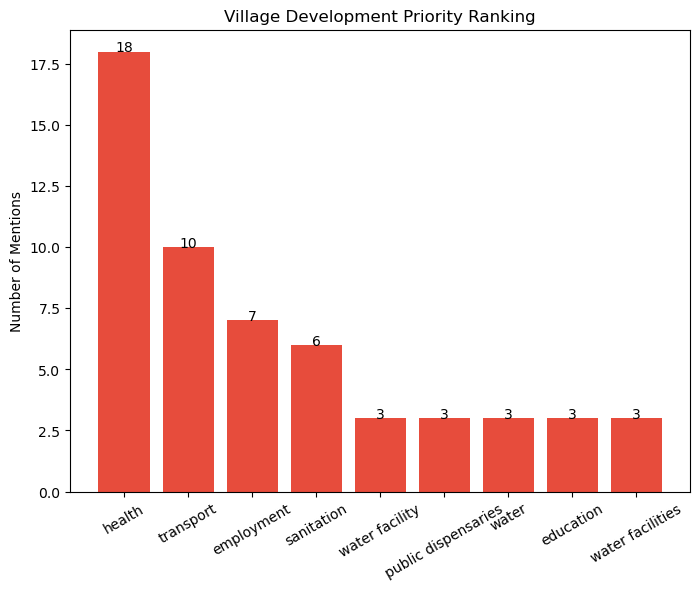

In [127]:
plt.figure(figsize=(8,6))
bars = plt.bar(urgency_summary.head(9).index, urgency_summary.head(9).values, color='#E74C3C')
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height()}",
             ha='center')
plt.title("Village Development Priority Ranking")
plt.ylabel("Number of Mentions")
plt.xticks(rotation=30)
plt.show()

# 2. Skill Gap Analysis

In [128]:
skill_trained = df['Skill-trained member in household'].value_counts()
skill_trained

Skill-trained member in household
Yes    47
No     37
Name: count, dtype: int64

In [129]:
percentage_skill_trained = round(df['Skill-trained member in household'].value_counts(normalize=True)*100,2)
percentage_skill_trained

Skill-trained member in household
Yes    55.95
No     44.05
Name: proportion, dtype: float64

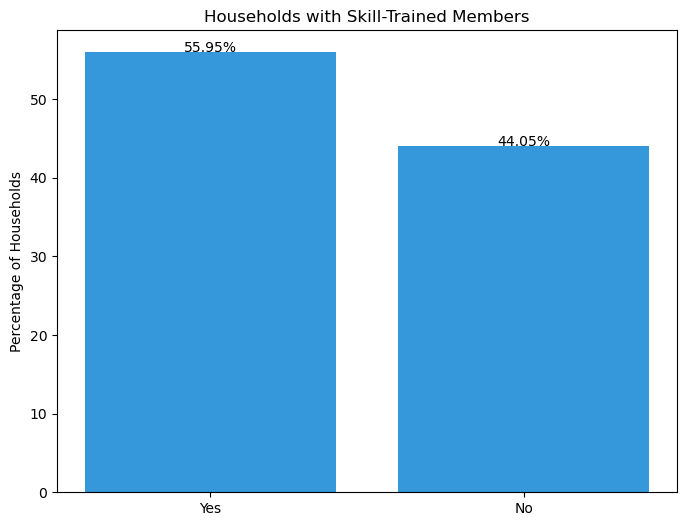

In [130]:
plt.figure(figsize=(8,6))
bars = plt.bar(percentage_skill_trained.index, percentage_skill_trained.values, color='#3498DB')
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.2f}%",
             ha='center')
plt.title("Households with Skill-Trained Members")
plt.ylabel("Percentage of Households")
plt.show()

In [131]:
df['Skills required'].value_counts()

Skills required
Agriculture                        52
Computer                           12
Tailoring                           5
Electrical                          4
Computer, Electrical                2
Agriculture, Electrical             2
Driving                             2
Agriculture, Computer               2
Agriculture, Driving                1
Tailoring, Computer, Electrical     1
Computer, Driving                   1
Name: count, dtype: int64

In [132]:
skills_required = df['Skills required'].str.split(',').explode().str.strip()

In [133]:
skills_required_counts = skills_required.value_counts()
skills_required_counts

Skills required
Agriculture    57
Computer       18
Electrical      9
Tailoring       6
Driving         4
Name: count, dtype: int64

In [134]:
percentage_skills_required = round(skills_required.value_counts(normalize=True)*100,2)
percentage_skills_required

Skills required
Agriculture    60.64
Computer       19.15
Electrical      9.57
Tailoring       6.38
Driving         4.26
Name: proportion, dtype: float64

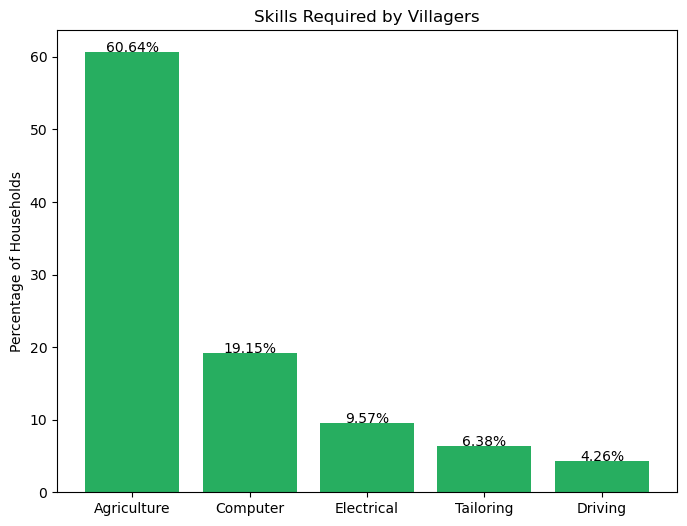

In [135]:
plt.figure(figsize=(8,6))
bars = plt.bar(percentage_skills_required.index, percentage_skills_required.values, color='#27AE60')
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.2f}%",
             ha='center')
plt.title("Skills Required by Villagers")
plt.ylabel("Percentage of Households")
plt.show()

# A. Poverty–Education–Migration Cycle Analysis

# 1. Income vs School Dropout (Poverty → Education)

In [136]:
income_dropout = pd.crosstab(df['Approx. Annual Household Income'], df['School dropout cases  in the household'], normalize='index') * 100
income_dropout

School dropout cases in the household,NO,Partia,YES
Approx. Annual Household Income,,,
<1 lakh,75.609756,2.439024,21.951220
1-3 lakh,82.142857,3.571429,14.285714
3-5 lakh,100.000000,0.000000,0.000000
>5 lakh,100.000000,0.000000,0.000000


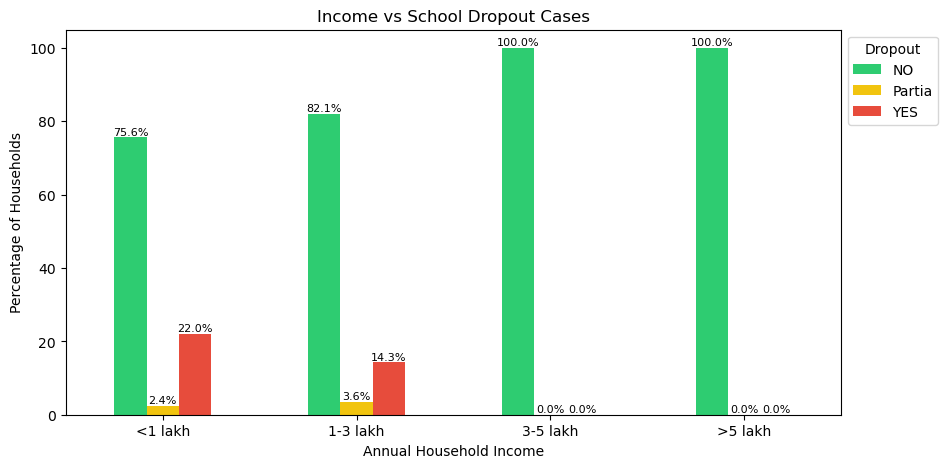

In [137]:
bars = income_dropout.plot(kind='bar', figsize=(10,5), color=['#2ECC71','#F1C40F','#E74C3C'])
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height()+0.1,
             f"{bar.get_height():.1f}%",
             ha='center',
             va='bottom',
             fontsize=8)
plt.title("Income vs School Dropout Cases")
plt.ylabel("Percentage of Households")
plt.xlabel("Annual Household Income")
plt.xticks(rotation=0)
plt.legend(title="Dropout", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# 2. Migration vs Reason for Dropout (Drivers)

In [138]:
migration_dropout_reason = round(pd.crosstab(df['Migration for employment'], df['Reason for dropout'], normalize='index') * 100,2)
migration_dropout_reason

Reason for dropout,Domestic work,Financial,Lack of interest,Migration
Migration for employment,,,,
Permanent,11.11,44.44,11.11,33.33
Seasonal,14.29,42.86,28.57,14.29


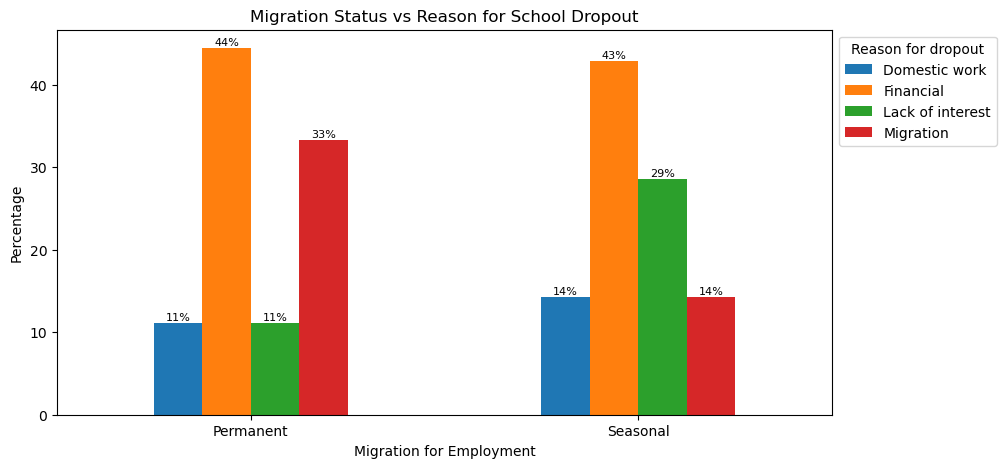

In [139]:
bars = migration_dropout_reason.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height()+0.1,
             f"{bar.get_height():.0f}%",
             ha='center',
             va='bottom',
             fontsize=8)
plt.title("Migration Status vs Reason for School Dropout")
plt.ylabel("Percentage")
plt.xlabel("Migration for Employment")
plt.xticks(rotation=0)
plt.legend(title="Reason for dropout", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# 3. Literacy vs Migration (Outcome)

In [140]:
literacy_migration = round(pd.crosstab(df['Literacy status of household'], df['Migration for employment'], normalize='index') * 100,2)
literacy_migration

Migration for employment,Permanent,Seasonal
Literacy status of household,,
All literate,66.67,33.33
Mostly illiterate,0.00,100.00
Partially literate,28.57,71.43


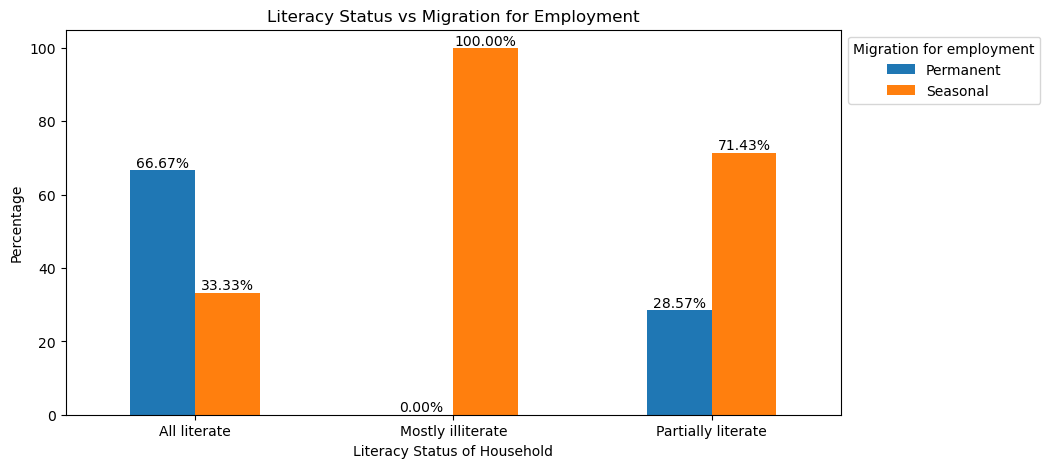

In [141]:
bars = literacy_migration.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.2f}%',
             ha='center',
             va='bottom')
plt.title("Literacy Status vs Migration for Employment")
plt.ylabel("Percentage")
plt.xlabel("Literacy Status of Household")
plt.xticks(rotation=0)
plt.legend(title="Migration for employment", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

In [142]:
round(pd.crosstab([df['Approx. Annual Household Income'], df['Migration for employment']], df['School dropout cases  in the household'], 
            normalize='index') * 100, 2)

School dropout cases  in the household                        NO  Partia  \
Approx. Annual Household Income Migration for employment                   
<1 lakh                         Permanent                  33.33    0.00   
                                Seasonal                   55.56    0.00   
1-3 lakh                        Permanent                  83.33   16.67   
                                Seasonal                   85.71    0.00   
3-5 lakh                        Permanent                 100.00    0.00   
                                Seasonal                  100.00    0.00   
>5 lakh                         Seasonal                  100.00    0.00   

School dropout cases  in the household                      YES  
Approx. Annual Household Income Migration for employment         
<1 lakh                         Permanent                 66.67  
                                Seasonal                  44.44  
1-3 lakh                        Permanent                  0.00  
                                Seasonal                  14.29  
3-5 lakh                        Permanent                  0.00  
                                Seasonal                   0.00  
>5 lakh                         Seasonal                   0.00

# Social Equity in Public Service Delivery

# 1. Health Access Inequality

# Social Category vs Type of Health Facility Used

In [143]:
health_access = round(pd.crosstab(df['Social Category'], df['Type of facility used'], normalize='index') * 100,2)
health_access

Type of facility used,PHC,Private,Sub-Centre
Social Category,,,
General,52.94,45.10,1.96
OBC,44.44,22.22,33.33
Scheduled Caste,34.78,65.22,0.00
Scheduled Tribe,100.00,0.00,0.00


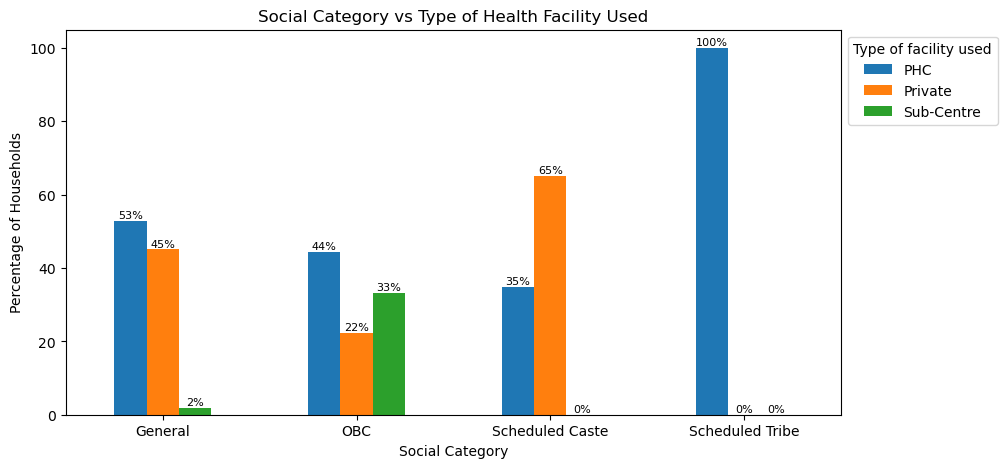

In [144]:
bars = health_access.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height()+0.1,
             f'{bar.get_height():.0f}%',
             ha='center',
             va='bottom',
             fontsize=8)
plt.title("Social Category vs Type of Health Facility Used")
plt.ylabel("Percentage of Households")
plt.xlabel("Social Category")
plt.xticks(rotation=0)
plt.legend(title="Type of facility used", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# Social Category vs ASHA/ANM Visits

In [145]:
asha_visits = round(pd.crosstab(df['Social Category'], df['ASHA/ANM visit'], normalize='index') * 100, 2)
asha_visits

ASHA/ANM visit,Never,Occasional,Regular
Social Category,,,
General,7.84,70.59,21.57
OBC,11.11,44.44,44.44
Scheduled Caste,13.04,47.83,39.13
Scheduled Tribe,100.00,0.00,0.00


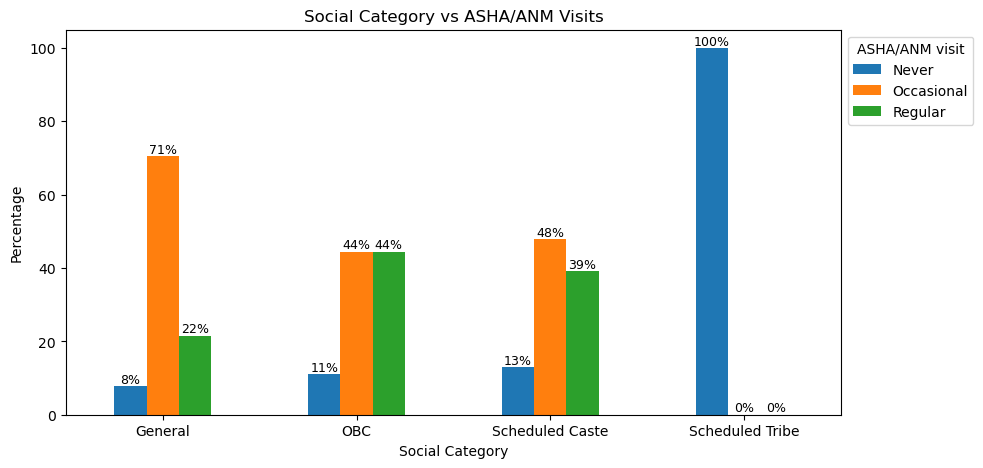

In [146]:
bars = asha_visits.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.0f}%',
             ha='center',
             va='bottom',
             fontsize=9)
plt.title("Social Category vs ASHA/ANM Visits")
plt.ylabel("Percentage")
plt.xlabel("Social Category")
plt.xticks(rotation=0)
plt.legend(title="ASHA/ANM visit", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# 2. Scheme Reach (Equity in Government Benefits)

# Social Category vs PM-JAY (Ayushman Bharat)

In [147]:
pmjay_access = round(pd.crosstab(df['Social Category'], df['Health Schemes   [Ayushman Bharat (PM-JAY)]'], normalize='index') * 100, 2)
pmjay_access

Health Schemes [Ayushman Bharat (PM-JAY)],Applied,Availed,Aware,Not aware
Social Category,,,,
General,11.76,27.45,33.33,27.45
OBC,22.22,11.11,22.22,44.44
Scheduled Caste,13.04,8.70,34.78,43.48
Scheduled Tribe,0.00,0.00,100.00,0.00


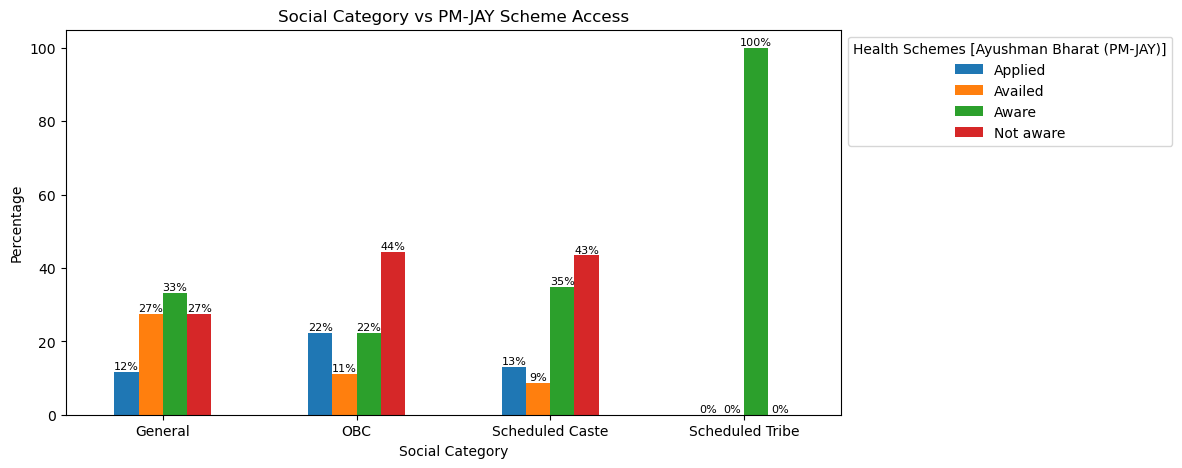

In [148]:
bars = pmjay_access.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height()+0.1,
             f'{bar.get_height():.0f}%',
             ha='center',
             va='bottom',
             fontsize=8)
plt.title("Social Category vs PM-JAY Scheme Access")
plt.ylabel("Percentage")
plt.xlabel("Social Category")
plt.xticks(rotation=0)
plt.legend(title="Health Schemes [Ayushman Bharat (PM-JAY)]", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# Social Category vs MGNREGA

In [149]:
mgnrega_access = round(pd.crosstab(df['Social Category'], df['Livelihood Schemes   [MGNREGA]'], normalize='index') * 100, 2)
mgnrega_access

Livelihood Schemes [MGNREGA],Applied,Availed,Aware,Not Aware
Social Category,,,,
General,5.88,3.92,54.90,35.29
OBC,0.00,0.00,33.33,66.67
Scheduled Caste,4.35,8.70,52.17,34.78
Scheduled Tribe,100.00,0.00,0.00,0.00


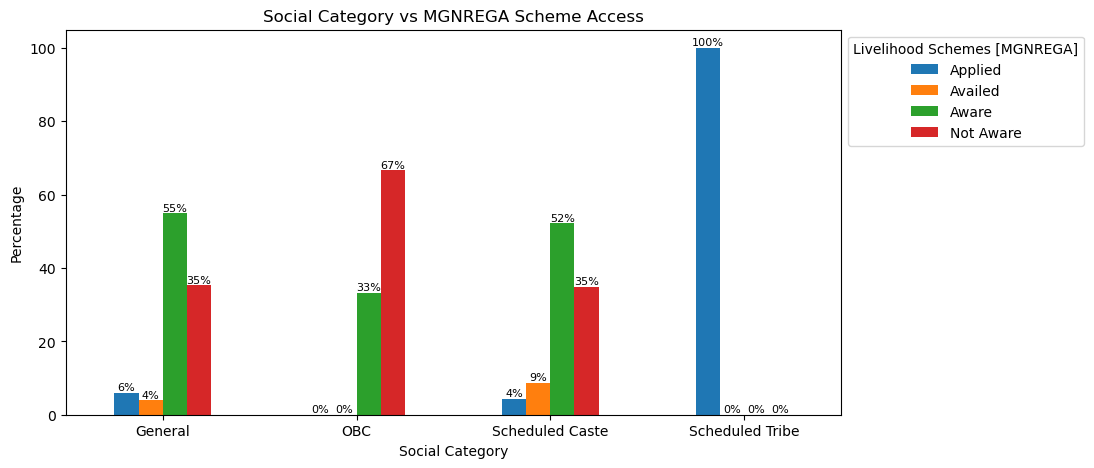

In [150]:
bars = mgnrega_access.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height()+0.1,
             f'{bar.get_height():.0f}%',
             ha='center',
             va='bottom',
             fontsize=8)
plt.title("Social Category vs MGNREGA Scheme Access")
plt.ylabel("Percentage")
plt.xlabel("Social Category")
plt.xticks(rotation=0)
plt.legend(title="Livelihood Schemes [MGNREGA]", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# 3. Digital Divide Analysis

# Social Category vs Access to Digital Devices

In [151]:
digital_divide = round(pd.crosstab(df['Social Category'], df['Access to digital devices'], normalize='index') * 100, 2)
digital_divide

Access to digital devices,Laptop,Smartphone,"Smartphone, Laptop"
Social Category,,,
General,4.17,81.25,14.58
OBC,0.00,100.00,0.00
Scheduled Caste,0.00,91.30,8.70


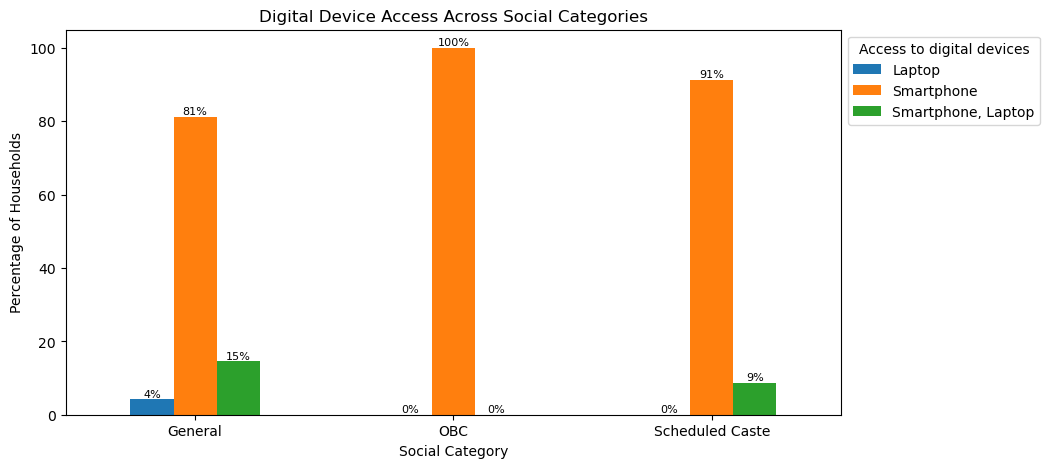

In [152]:
bars = digital_divide.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height()+0.1,
             f'{bar.get_height():.0f}%',
             ha='center',
             va='bottom',
             fontsize=8)
plt.title("Digital Device Access Across Social Categories")
plt.ylabel("Percentage of Households")
plt.xlabel("Social Category")
plt.xticks(rotation=0)
plt.legend(title="Access to digital devices", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# Women's Economic Agency vs. Decision-Making Power

# 1. Income Activity vs Decision-Making Power

In [153]:
decision_income = round(pd.crosstab(df['Household women  engaged in income activity'], df['Role of women in decision-making'], normalize='index') 
                        * 100, 2)
decision_income

Role of women in decision-making,High,Low,Moderate
Household women engaged in income activity,,,
No,16.42,13.43,70.15
Yes,29.41,11.76,58.82


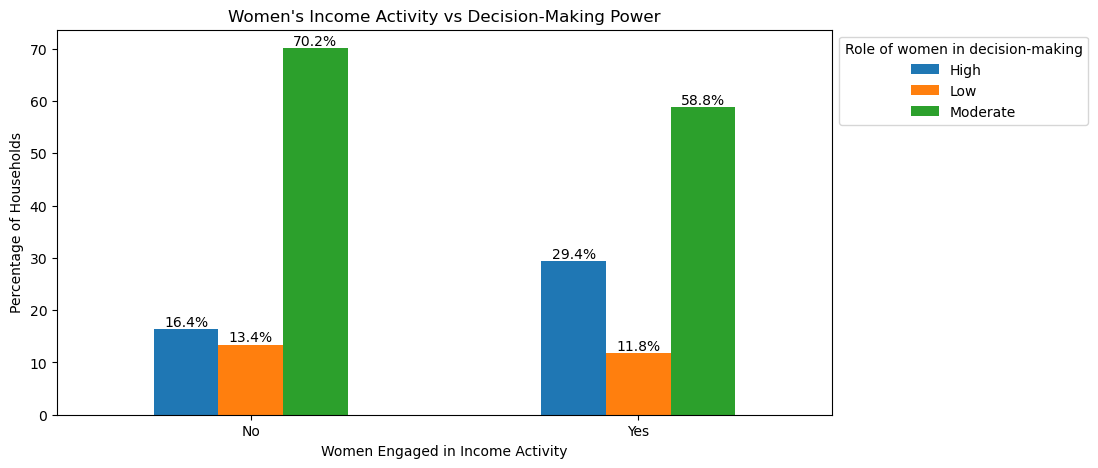

In [154]:
bars = decision_income.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.1f}%',
             ha='center',
             va='bottom')
plt.title("Women's Income Activity vs Decision-Making Power")
plt.ylabel("Percentage of Households")
plt.xlabel("Women Engaged in Income Activity")
plt.xticks(rotation=0)
plt.legend(title="Role of women in decision-making", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# 2. SHG Membership vs Decision-Making Power

In [155]:
shg_decision = round(pd.crosstab(df['SHG membership'], df['Role of women in decision-making'], normalize='index') * 100, 2)
shg_decision

Role of women in decision-making,High,Low,Moderate
SHG membership,,,
No,18.75,12.5,68.75
Yes,25.00,25.0,50.00


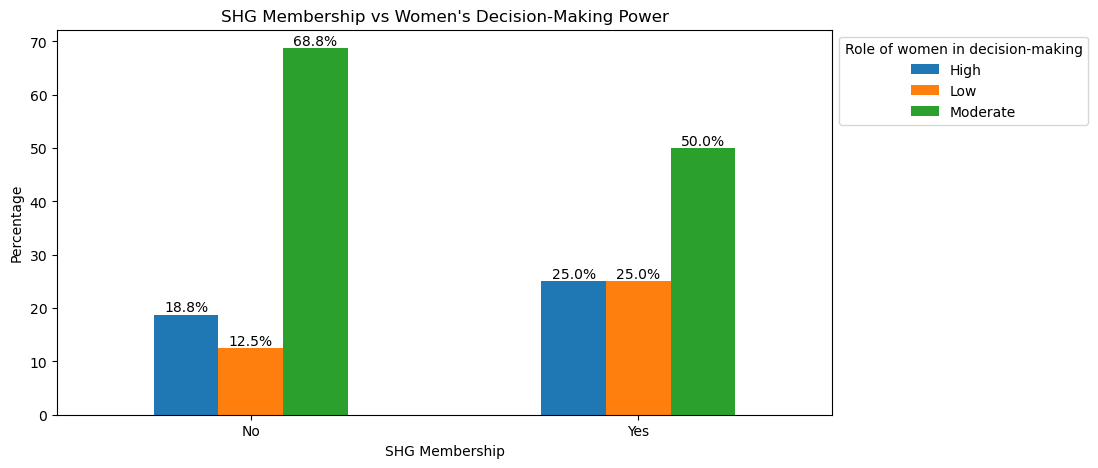

In [156]:
bars = shg_decision.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.1f}%',
             ha='center',
             va='bottom')
plt.title("SHG Membership vs Women's Decision-Making Power")
plt.ylabel("Percentage")
plt.xlabel("SHG Membership")
plt.xticks(rotation=0)
plt.legend(title="Role of women in decision-making", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# 3. SHG Membership vs Awareness of Women Schemes

In [157]:
shg_scheme = round(pd.crosstab(df['SHG membership'], df['Women Schemes   [NRLM]'], normalize='index') * 100, 2)
shg_scheme

Women Schemes [NRLM],Applied,Availed,Aware,Not Aware
SHG membership,,,,
No,1.25,1.25,22.5,75.0
Yes,0.00,0.00,25.0,75.0


In [158]:
shg_scheme = round(pd.crosstab(df['SHG membership'], df['Women Schemes   [Pradhan Mantri Matru Vandana Yojana]'], normalize='index') * 100, 2)
shg_scheme

Women Schemes [Pradhan Mantri Matru Vandana Yojana],Applied,Availed,Aware,Not Aware
SHG membership,,,,
No,1.25,2.5,35.0,61.25
Yes,0.00,0.0,25.0,75.00


In [159]:
shg_scheme = round(pd.crosstab(df['SHG membership'], df['Women Schemes   [Beti Bachao Beti Padhao]'], normalize='index') * 100, 2)
shg_scheme

Women Schemes [Beti Bachao Beti Padhao],Applied,Availed,Aware,Not Aware
SHG membership,,,,
No,2.5,2.5,58.75,36.25
Yes,0.0,25.0,75.00,0.00


In [160]:
shg_scheme = round(pd.crosstab(df['SHG membership'], df['Women Schemes   [Sukanya Samriddhi]'], normalize='index') * 100, 2)
shg_scheme

Women Schemes [Sukanya Samriddhi],Applied,Availed,Aware,Not Aware
SHG membership,,,,
No,3.75,1.25,35.0,60.0
Yes,0.00,0.00,25.0,75.0


# Health Outcomes and Environmental Sanitation

# 1. Environmental Link

In [161]:
pond_disease = round(pd.crosstab( df['Condition of pond'], df['Common diseases'], normalize='index') * 100,2)
pond_disease

Common diseases,BP,"BP, Diabetes","BP, None","BP, Respiratory","BP, TB",Diabetes,"TB, None","TB, Respiratory"
Condition of pond,,,,,,,,
Clean,33.33,0.00,0.00,0.00,0.00,33.33,0.0,33.33
Highly polluted,44.44,22.22,2.78,5.56,2.78,22.22,0.0,0.00
Partially polluted,20.00,20.00,0.00,0.00,0.00,40.00,20.0,0.00


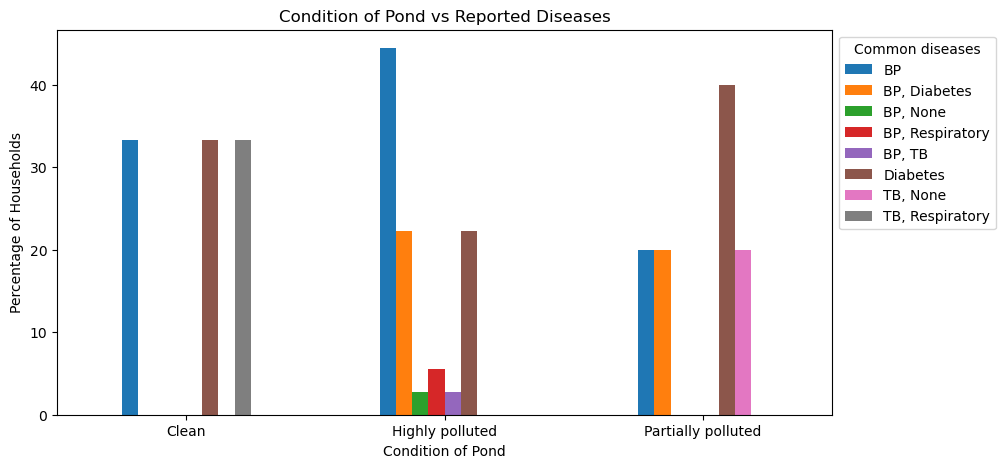

In [162]:
pond_disease.plot(kind='bar', figsize=(10,5))
plt.title("Condition of Pond vs Reported Diseases")
plt.ylabel("Percentage of Households")
plt.xlabel("Condition of Pond")
plt.xticks(rotation=0)
plt.legend(title="Common diseases", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# 2. Solid Waste Disposal vs Diseases

In [163]:
waste_disease = round(pd.crosstab(df['Solid waste disposal method'], df['Common diseases'], normalize='index') * 100, 2)
waste_disease

Common diseases,BP,"BP, Diabetes","BP, None","BP, Respiratory","BP, TB",Diabetes,"TB, None","TB, Respiratory"
Solid waste disposal method,,,,,,,,
Burning,100.00,0.00,0.0,0.00,0.0,0.00,0.0,0.0
Open dumping,35.14,21.62,2.7,5.41,2.7,27.03,2.7,2.7
"Open dumping, Burning",50.00,25.00,0.0,0.00,0.0,25.00,0.0,0.0


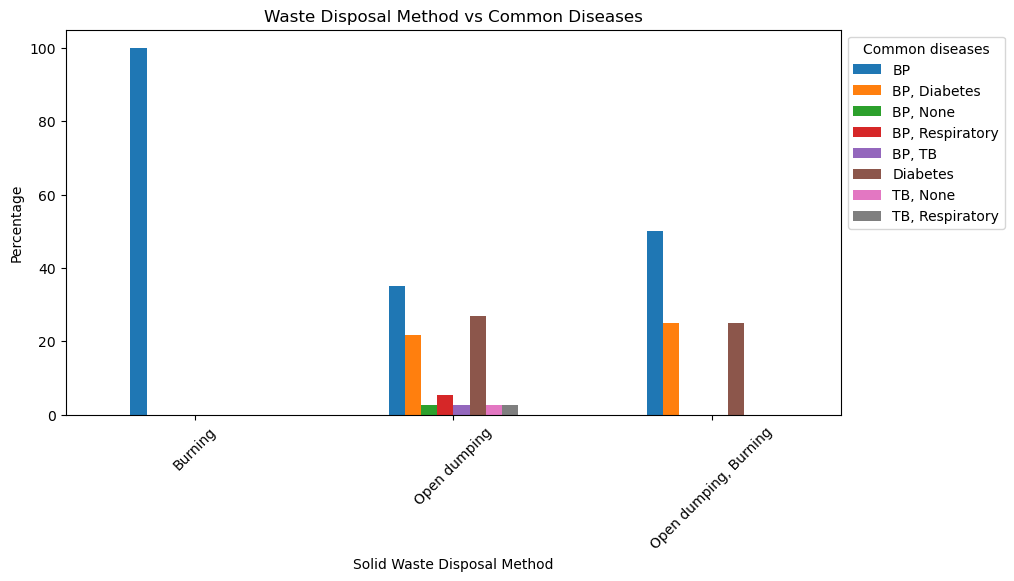

In [164]:
waste_disease.plot(kind='bar', figsize=(10,5))
plt.title("Waste Disposal Method vs Common Diseases")
plt.ylabel("Percentage")
plt.xlabel("Solid Waste Disposal Method")
plt.xticks(rotation=45)
plt.legend(title="Common diseases", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# 3. Hygiene Practices vs Diseases

In [165]:
handwash_disease = round(pd.crosstab(df['Handwashing with soap'], df['Common diseases'], normalize='index') * 100, 2)
handwash_disease

Common diseases,BP,"BP, Diabetes","BP, None","BP, Respiratory","BP, TB",Diabetes,"TB, None","TB, Respiratory"
Handwashing with soap,,,,,,,,
Always,42.86,21.43,2.38,4.76,2.38,21.43,2.38,2.38
Sometimes,0.00,0.00,0.00,0.00,0.00,100.00,0.00,0.00


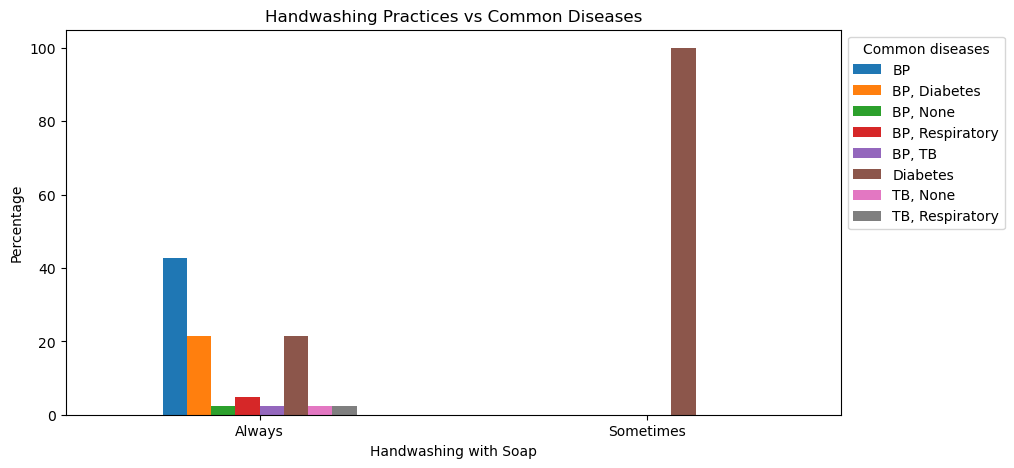

In [166]:
handwash_disease.plot(kind='bar', figsize=(10,5))
plt.title("Handwashing Practices vs Common Diseases")
plt.ylabel("Percentage")
plt.xlabel("Handwashing with Soap")
plt.xticks(rotation=0)
plt.legend(title="Common diseases", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

In [167]:
toilet_disease = round(pd.crosstab(df['Toilet availability'], df['Common diseases'], normalize='index') * 100, 2)
toilet_disease

Common diseases,BP,"BP, Diabetes","BP, None","BP, Respiratory","BP, TB",Diabetes,"TB, None","TB, Respiratory"
Toilet availability,,,,,,,,
NO,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
YES,39.53,20.93,2.33,4.65,2.33,25.58,2.33,2.33


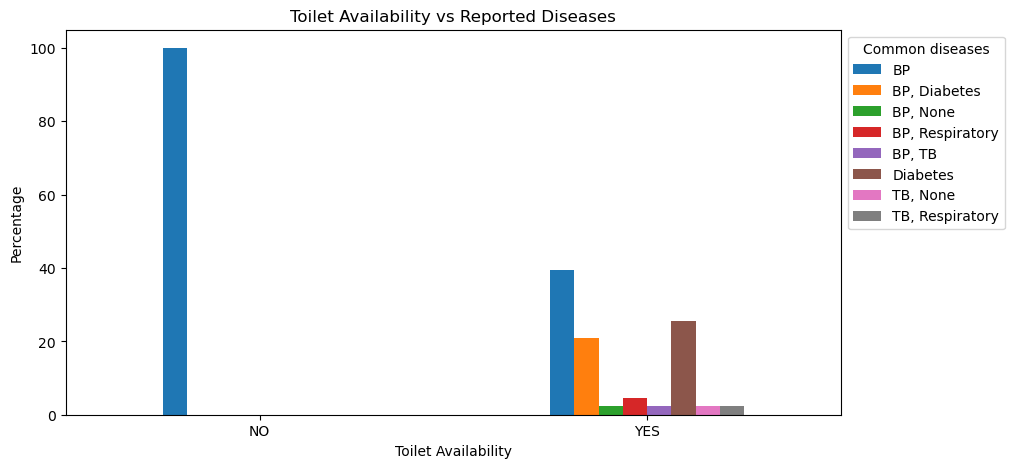

In [168]:
toilet_disease.plot(kind='bar', figsize=(10,5))
plt.title("Toilet Availability vs Reported Diseases")
plt.ylabel("Percentage")
plt.xlabel("Toilet Availability")
plt.xticks(rotation=0)
plt.legend(title="Common diseases", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# Infrastructure Accessibility & Service Utilization

# 1. Distance to Health Facility vs Immunization Status

In [169]:
health_distance_immunization = round(pd.crosstab(df['Distance to nearest health facility'], df['Immunization status of children (0-5)'], 
                                                 normalize='index') * 100, 2)
health_distance_immunization

Immunization status of children (0-5),Fully,Not immunised,Partially
Distance to nearest health facility,,,
1-5 km,74.42,18.60,6.98
<1 km,80.00,20.00,0.00
>5 km,52.38,19.05,28.57


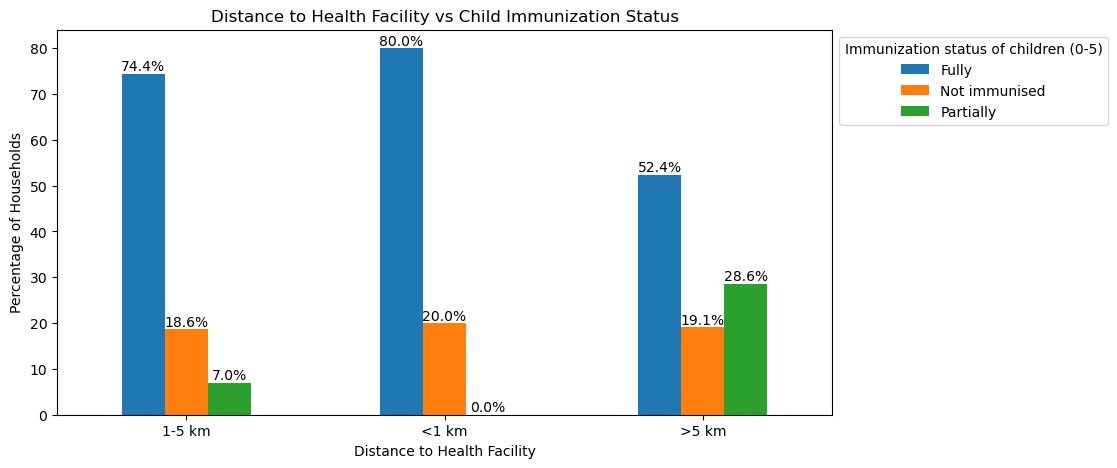

In [170]:
bars = health_distance_immunization.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.1f}%',
             ha='center',
             va='bottom')
plt.title("Distance to Health Facility vs Child Immunization Status")
plt.ylabel("Percentage of Households")
plt.xlabel("Distance to Health Facility")
plt.legend(title='Immunization status of children (0-5)', bbox_to_anchor=(1,1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

# 2. Distance to School vs Girls' Education

In [171]:
school_distance_girls = round(pd.crosstab(df['Distance to nearest school'], df['Girls continuing education beyond Class X'], normalize='index') 
                              * 100, 2)
school_distance_girls

Girls continuing education beyond Class X,No,YES
Distance to nearest school,,
1-3 km,25.81,74.19
<1 km,47.06,52.94
>3 km,31.58,68.42


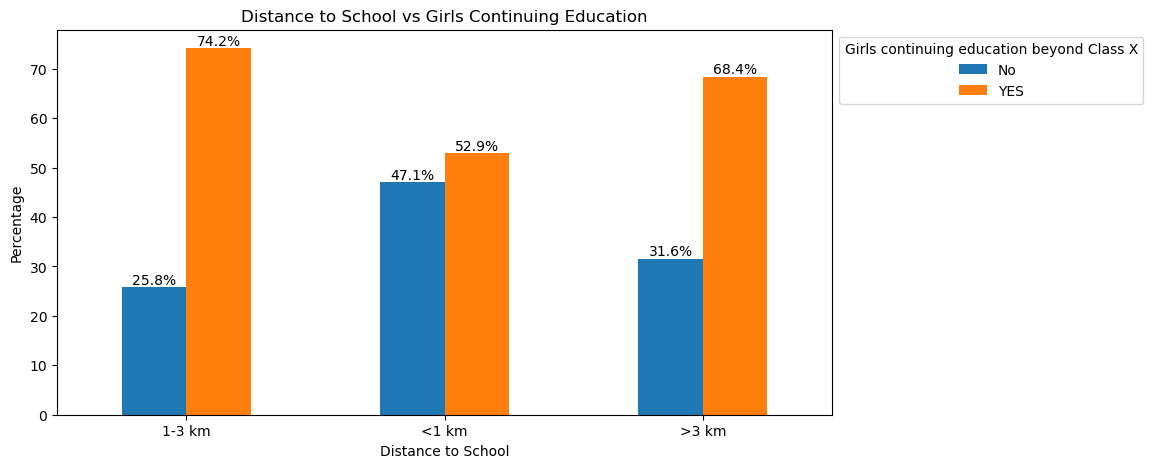

In [172]:
bars = school_distance_girls.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.1f}%',
             ha='center',
             va='bottom')
plt.title("Distance to School vs Girls Continuing Education")
plt.ylabel("Percentage")
plt.xlabel("Distance to School")
plt.legend(title="Girls continuing education beyond Class X", bbox_to_anchor=(1,1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

# 3. Behavioral Shift in Healthcare Choice

In [173]:
distance_facility_type = round(pd.crosstab(df['Distance to nearest health facility'], df['Type of facility used'], normalize='index') * 100, 2)
distance_facility_type

Type of facility used,PHC,Private,Sub-Centre
Distance to nearest health facility,,,
1-5 km,72.09,27.91,0.00
<1 km,30.00,70.00,0.00
>5 km,14.29,66.67,19.05


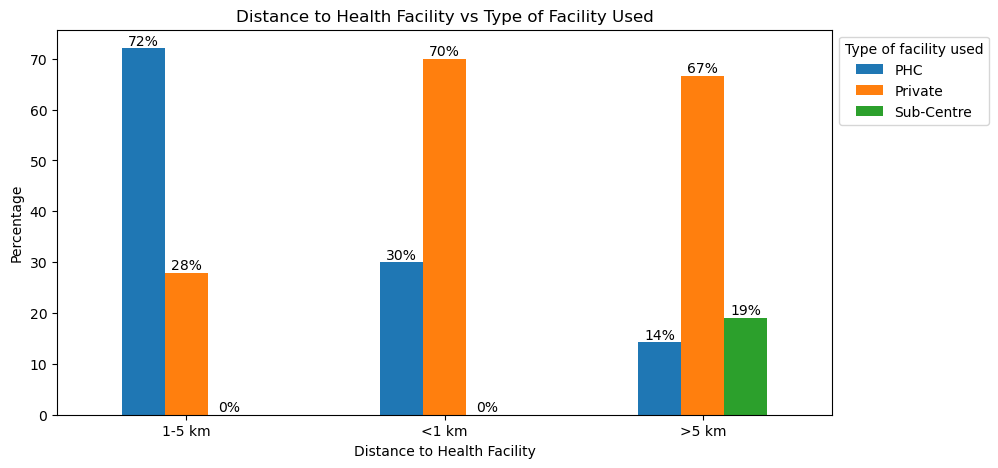

In [174]:
bars = distance_facility_type.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.0f}%',
             ha='center',
             va='bottom')
plt.title("Distance to Health Facility vs Type of Facility Used")
plt.ylabel("Percentage")
plt.xlabel("Distance to Health Facility")
plt.legend(title="Type of facility used", bbox_to_anchor=(1,1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

# Village Governance & Civic Engagement

# 1. Knowledge–Action Gap

In [175]:
awareness_participation = round(pd.crosstab(df['Awareness about Gram Sabha meetings'], df['Participation in village development'], normalize='index')
                                * 100, 2)
awareness_participation

Participation in village development,Never,Occasional,Regular
Awareness about Gram Sabha meetings,,,
No,50.00,40.00,10.00
Yes,29.63,40.74,29.63


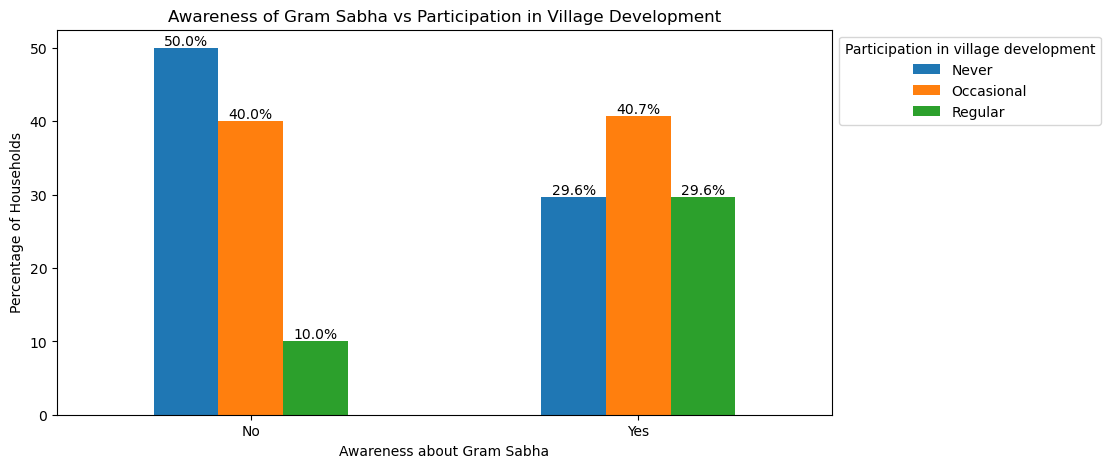

In [176]:
bars = awareness_participation.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.1f}%',
             ha='center',
             va='bottom')
plt.title("Awareness of Gram Sabha vs Participation in Village Development")
plt.ylabel("Percentage of Households")
plt.xlabel("Awareness about Gram Sabha")
plt.legend(title="Participation in village development", bbox_to_anchor=(1,1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

# 2. Migration vs Participation

In [177]:
migration_participation = round(pd.crosstab(df['Migration for employment'], df['Participation in village development'], normalize='index') * 100, 2)
migration_participation

Participation in village development,Never,Occasional,Regular
Migration for employment,,,
Permanent,25.00,41.67,33.33
Seasonal,31.58,57.89,10.53


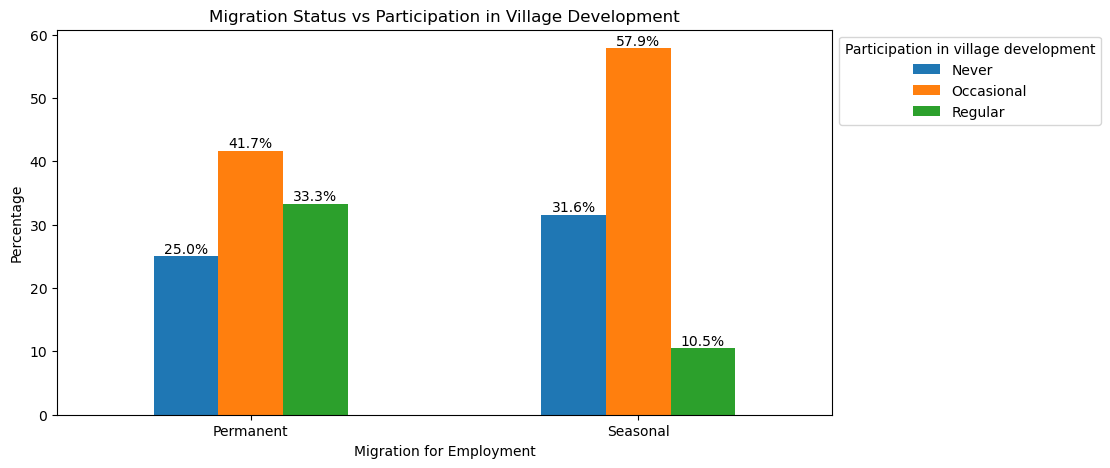

In [178]:
bars = migration_participation.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.1f}%',
             ha='center',
             va='bottom')
plt.title("Migration Status vs Participation in Village Development")
plt.ylabel("Percentage")
plt.xlabel("Migration for Employment")
plt.legend(title="Participation in village development", bbox_to_anchor=(1,1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

# 3. Social Category vs Participation (Inclusion)

In [179]:
social_participation = round(pd.crosstab(df['Social Category'], df['Participation in village development'], normalize='index') * 100, 2)
social_participation

Participation in village development,Never,Occasional,Regular
Social Category,,,
General,37.25,37.25,25.49
OBC,55.56,33.33,11.11
Scheduled Caste,26.09,52.17,21.74
Scheduled Tribe,100.00,0.00,0.00


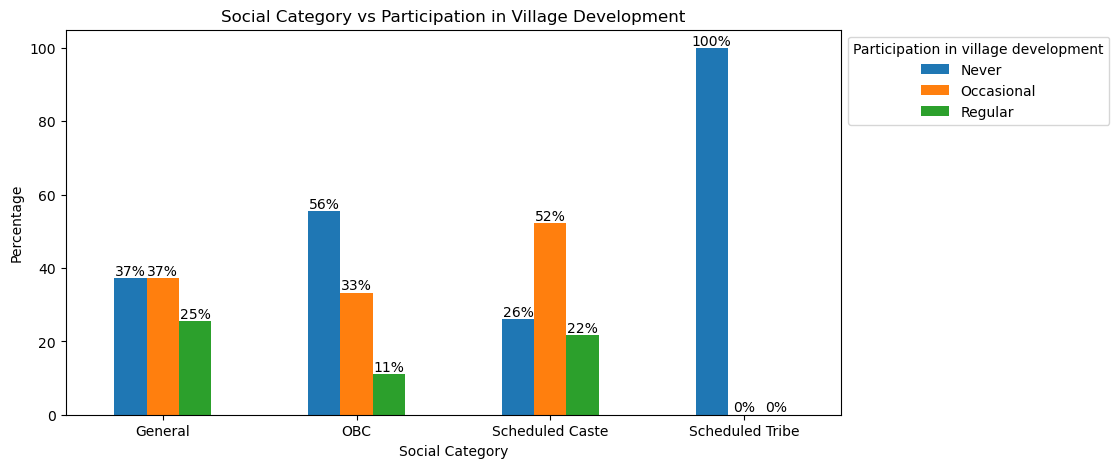

In [180]:
bars = social_participation.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.0f}%',
             ha='center',
             va='bottom')
plt.title("Social Category vs Participation in Village Development")
plt.ylabel("Percentage")
plt.xlabel("Social Category")
plt.legend(title="Participation in village development", bbox_to_anchor=(1,1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

# Skill-Demand Mismatch for Livelihoods

# 1. Skill Demand vs Current Occupation (Gap Analysis)

In [181]:
skill_occupation = pd.crosstab(df['Main Occupation'], df['Skills required'])
skill_occupation

Skills required,Agriculture,"Agriculture, Computer","Agriculture, Driving","Agriculture, Electrical",Computer,"Computer, Driving","Computer, Electrical",Driving,Electrical,Tailoring,"Tailoring, Computer, Electrical"
Main Occupation,,,,,,,,,,,
Agriculture,32,2,0,1,3,0,1,1,0,1,0
"Agriculture, Business",1,0,0,0,0,0,0,0,0,0,0
"Agriculture, Labour",1,0,0,0,0,0,0,0,0,0,0
"Agriculture, Service",0,0,0,1,0,0,0,0,0,1,0
Business,2,0,0,0,1,0,0,0,1,1,0
Labour,13,0,0,0,0,0,1,0,2,0,1
"Labour, Service",0,0,1,0,0,0,0,0,0,0,0
Service,3,0,0,0,7,1,0,1,1,2,0
"Service, Business",0,0,0,0,1,0,0,0,0,0,0


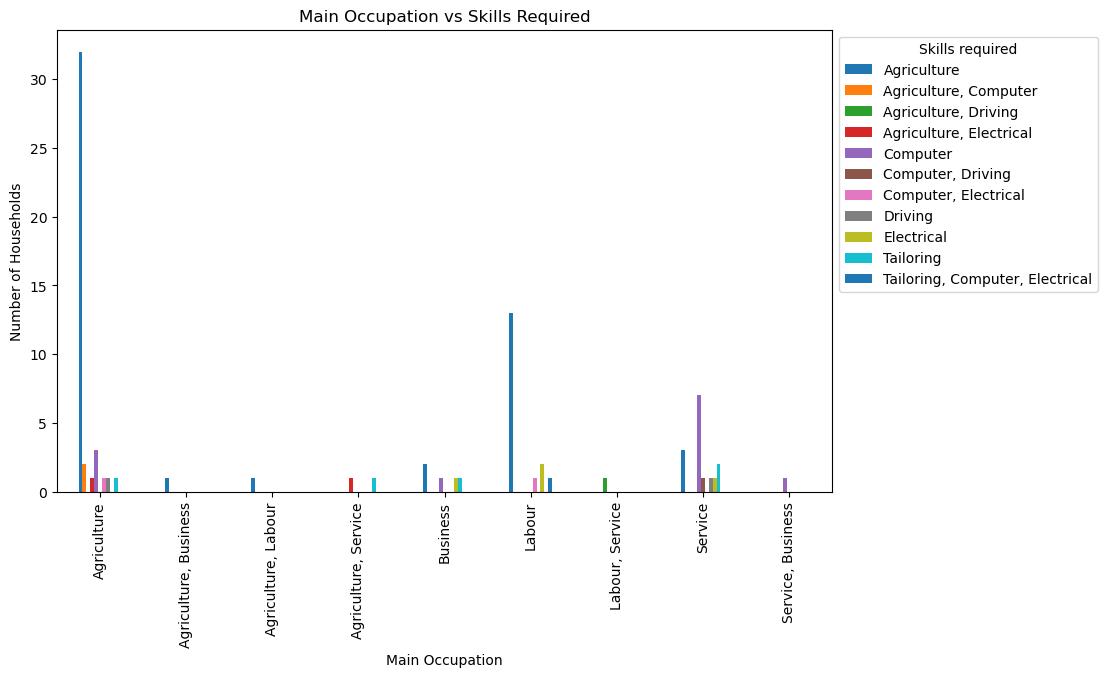

In [182]:
skill_occupation.plot(kind='bar', figsize=(10,6))
plt.title("Main Occupation vs Skills Required")
plt.ylabel("Number of Households")
plt.xlabel("Main Occupation")
plt.legend(title="Skills required", bbox_to_anchor=(1,1), loc='upper left')
plt.xticks(rotation=90)
plt.show()

# 2. Skill Training vs Household Income (Future Readiness)

In [183]:
skill_income = round(pd.crosstab(df['Skill-trained member in household'], df['Approx. Annual Household Income'], normalize='index') * 100, 2)
skill_income

Approx. Annual Household Income,<1 lakh,1-3 lakh,3-5 lakh,>5 lakh
Skill-trained member in household,,,,
No,56.76,32.43,10.81,0.00
Yes,42.55,34.04,12.77,10.64


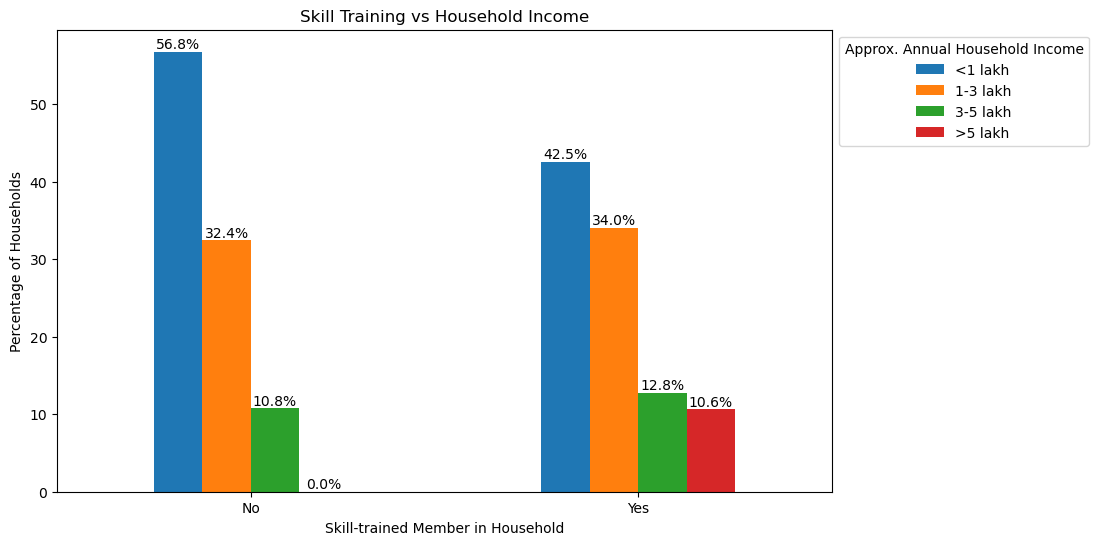

In [184]:
bars = skill_income.plot(kind='bar', figsize=(10,6))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.1f}%',
             ha='center',
             va='bottom')
plt.title("Skill Training vs Household Income")
plt.ylabel("Percentage of Households")
plt.xlabel("Skill-trained Member in Household")
plt.legend(title="Approx. Annual Household Income", bbox_to_anchor=(1,1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

# 3. Skills Required Distribution

In [185]:
skills_demand = df['Skills required'].value_counts()
skills_demand

Skills required
Agriculture                        52
Computer                           12
Tailoring                           5
Electrical                          4
Computer, Electrical                2
Agriculture, Electrical             2
Driving                             2
Agriculture, Computer               2
Agriculture, Driving                1
Tailoring, Computer, Electrical     1
Computer, Driving                   1
Name: count, dtype: int64

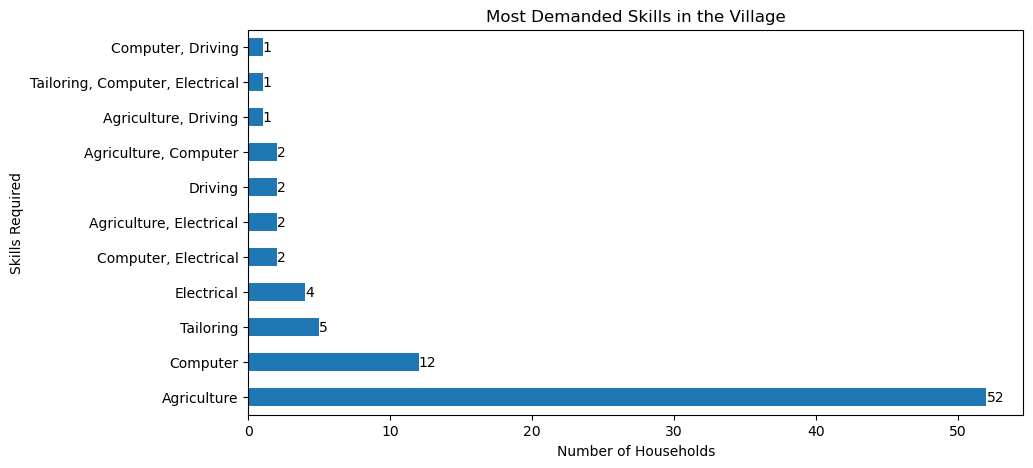

In [186]:
bars = skills_demand.plot(kind='barh', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_width(),
             bar.get_y()+ bar.get_height()/2,
             f'{bar.get_width()}',
             va='center')
plt.title("Most Demanded Skills in the Village")
plt.xlabel("Number of Households")
plt.ylabel("Skills Required")
plt.show()